# Immunotherapy Response in Melanoma: Longitudinal Single-Cell Analysis

**Dataset**: Sade-Feldman et al., Cell 2018 (GSE120575)

This notebook shows how to analyze longitudinal single-cell data from a clinical immunotherapy study, comparing immune dynamics between responders and non-responders to anti-PD-1 therapy.

> **Observational comparison, not a randomized experiment.** Response status is a *post-treatment outcome*, not a randomly assigned treatment. DiD contrasts here estimate *associations* between response and immune trajectory — they do not identify causal treatment effects. See Limitations for details.

## Background

Sade-Feldman et al. (Cell 2018) profiled tumor-infiltrating immune cells from melanoma patients **before and during** anti-PD-1 checkpoint inhibitor therapy. This landmark study identified transcriptional programs associated with clinical response.

### Study Design

**This is a prospective longitudinal study:**
- Patients received anti-PD-1 immunotherapy (pembrolizumab or nivolumab)
- Tumor biopsies collected **Pre-treatment** (baseline) and **Post-treatment** (on therapy)
- Response assessed by RECIST criteria: Complete/Partial Response vs Progressive Disease

**Key biological questions:**
- Do responders and non-responders have different baseline immune states?
- How does the immune microenvironment change with therapy?
- Are there response-specific trajectories (Difference-in-Differences)?

> **Note on study design**: Because response is defined *post-treatment* (RECIST criteria),
> groups are *observational*, not randomized. The DiD framework tests whether immune trajectories
> *differ by response status* — it cannot establish that treatment *caused* those differences.
> Confounders correlated with both response and immune dynamics remain possible.

### Analysis Strategy

1. **Cross-sectional comparisons**: Responder vs Non-responder at each timepoint
2. **Within-arm longitudinal**: Pre→Post changes within each response group
3. **Difference-in-Differences (DiD)**: Do responders change differently than non-responders?

**Statistical considerations:**
- Participant-level aggregation to avoid pseudoreplication
- FDR correction for multiple testing
- Bootstrap inference for small sample sizes

## 1. Setup


In [1]:
# Imports - consolidated
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
# Note: We do NOT suppress UserWarning — sctrial issues important
# statistical caveats (e.g. low-cluster reliability) as UserWarnings.
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

import sctrial as st

# Configuration
MIN_GENES_FOR_SCORE = 5
MIN_PARTICIPANTS_FOR_COMPARISON = 3
FDR_ALPHA = 0.25  # Exploratory threshold — all results flagged at this level
                   # are hypothesis-generating, NOT confirmatory. Use 0.05 for
                   # confirmatory analyses. See GSEA FAQ for precedent.
SEED = 42
RUN_PYMC = False        # Set True to run Bayesian DiD (slow; may crash on arm64)
MAX_PLOT_FEATURES = 9  # Cap visualization loops to avoid very large grids
RESPONSE_COL = "response_harmonized"

pd.options.mode.chained_assignment = None
print(f"sctrial version: {st.__version__ if hasattr(st, '__version__') else 'dev'}")

def _fmt_fdr(v):
    """Format FDR/p-value: scientific notation for very small values."""
    return f"{v:.2e}" if v < 0.001 else f"{v:.3f}"


sctrial version: 0.3.3


## 2. Data Loading and Processing


In [2]:
# Dataset loader (from sctrial)
# Also available as st.load_sade_feldman()
from sctrial.datasets import load_sade_feldman


### Load processed AnnData

We harmonize response labels at the **participant level** (majority label) because a few participants have mixed response annotations across cells/samples. Mixed cases are reported below.


In [3]:
# Load data - using full dataset for reliable longitudinal analysis
adata = load_sade_feldman(allow_download=True, max_cells_per_participant_visit=None)

# Harmonize response labels at participant level using package API
# (assigns majority-vote label for participants with mixed response annotations)
adata = st.harmonize_response(adata)

RESPONSE_COL = "response_harmonized"

# Print dataset summary
print("")
print("=== Dataset Summary ===")
print(f"Cells: {adata.n_obs:,}")
print(f"Genes: {adata.n_vars:,}")
print(f"Participants: {adata.obs['participant_id'].nunique()}")
print(f"Original response labels: {adata.obs['response'].unique().tolist()}")
print(f"Harmonized response labels: {adata.obs[RESPONSE_COL].unique().tolist()}")
print(f"Visits: {adata.obs['visit'].unique().tolist()}")

# Detailed pairing analysis - Identifies participants with Pre-only, Post-only or both
print("")
print("=== Longitudinal Pairing Analysis ===")
participant_visits = adata.obs.groupby("participant_id")["visit"].apply(set).reset_index()
participant_visits["has_Pre"] = participant_visits["visit"].apply(lambda x: "Pre" in x)
participant_visits["has_Post"] = participant_visits["visit"].apply(lambda x: "Post" in x)
participant_visits["is_paired"] = participant_visits["has_Pre"] & participant_visits["has_Post"]

# Add harmonized response info
dominant_response = adata.obs.groupby("participant_id")[RESPONSE_COL].first()
participant_visits[RESPONSE_COL] = participant_visits["participant_id"].map(dominant_response)

print("")
print(f"Total participants: {len(participant_visits)}")
print(f"  Pre only: {(participant_visits['has_Pre'] & ~participant_visits['has_Post']).sum()}")
print(f"  Post only: {(~participant_visits['has_Pre'] & participant_visits['has_Post']).sum()}")
print(f"  Both (paired): {participant_visits['is_paired'].sum()}")

paired_by_resp = participant_visits[participant_visits["is_paired"]].groupby(RESPONSE_COL).size()
print("")
print("Paired participants by response (harmonized):")
for resp, count in paired_by_resp.items():
    print(f"  {resp}: {count}")

print("")
print(f"Obs columns: {sorted(adata.obs.columns.tolist())}")



=== Dataset Summary ===
Cells: 16,291
Genes: 55,330
Participants: 32
Original response labels: ['Non-responder', 'Responder']
Harmonized response labels: ['Non-responder', 'Responder']
Visits: ['Pre', 'Post']

=== Longitudinal Pairing Analysis ===

Total participants: 32
  Pre only: 8
  Post only: 13
  Both (paired): 11

Paired participants by response (harmonized):
  Non-responder: 8
  Responder: 3

Obs columns: ['Sample name', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'annotation_source', 'cd8_state', 'cd8_subcluster', 'cell_type', 'cell_type_denovo', 'cell_type_published', 'characteristics: therapy', 'clinical_response_recist', 'cluster_published', 'description', 'leide

### Quick exploratory summaries


=== Sample Sizes ===

Cells per Response x Visit:


visit,Post,Pre
response_harmonized,,
Non-responder,8151,3458
Responder,2212,2470



Participants per Response x Visit:


visit,Post,Pre
response_harmonized,,
Non-responder,18,11
Responder,6,8


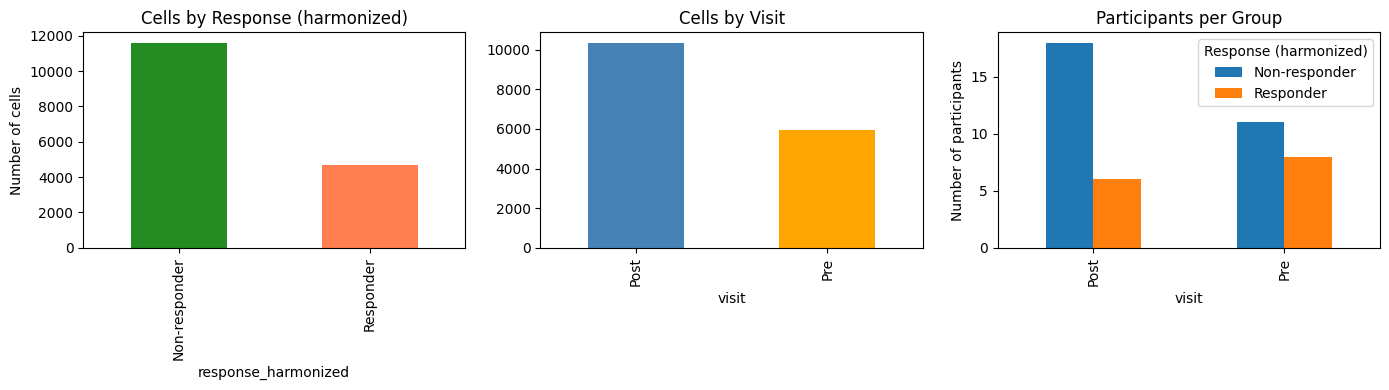

In [4]:
# Sample size summary
print("=== Sample Sizes ===")
print("")

# Cells per group
cell_counts = adata.obs.groupby([RESPONSE_COL, "visit"], observed=True).size().unstack(fill_value=0)
print("Cells per Response x Visit:")
display(cell_counts)

# Participants per group
participant_counts = (
    adata.obs
    .groupby([RESPONSE_COL, "visit"], observed=True)["participant_id"]
    .nunique()
    .unstack(fill_value=0)
)
print("")
print("Participants per Response x Visit:")
display(participant_counts)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Cells by response
adata.obs[RESPONSE_COL].value_counts().plot(
    kind="bar", ax=axes[0], color=["forestgreen", "coral"]
)
axes[0].set_title("Cells by Response (harmonized)")
axes[0].set_ylabel("Number of cells")

# Cells by visit
adata.obs["visit"].value_counts().plot(
    kind="bar", ax=axes[1], color=["steelblue", "orange"]
)
axes[1].set_title("Cells by Visit")

# Participants per group
participant_counts.T.plot(kind="bar", ax=axes[2])
axes[2].set_title("Participants per Group")
axes[2].set_ylabel("Number of participants")
axes[2].legend(title="Response (harmonized)")

plt.tight_layout()
plt.show()


## 3. Trial Design and Timepoint Strategy


In [5]:
# Define study design
visit_col = "visit"
adata.obs[visit_col] = adata.obs[visit_col].astype(str)
visits = [v for v in ["Pre", "Post"] if v in adata.obs[visit_col].unique()]
print(f"Available visits: {visits}")

# Participant-level response mapping (harmonized)
participant_response = adata.obs.groupby("participant_id")[RESPONSE_COL].first()

# Check longitudinal pairing (participant level)
participant_summary = (
    adata.obs.groupby("participant_id")[visit_col].apply(set).reset_index()
)
participant_summary["has_Pre"] = participant_summary[visit_col].apply(lambda x: "Pre" in x)
participant_summary["has_Post"] = participant_summary[visit_col].apply(lambda x: "Post" in x)
participant_summary["is_paired"] = participant_summary["has_Pre"] & participant_summary["has_Post"]
participant_summary[RESPONSE_COL] = participant_summary["participant_id"].map(participant_response)

paired_ids = set(participant_summary.loc[participant_summary["is_paired"], "participant_id"])
n_paired = len(paired_ids)

# Paired participants by response (harmonized)
# Dict of response -> number of paired participants
paired_by_response = (
    participant_summary[participant_summary["is_paired"]]
    .groupby(RESPONSE_COL)
    .size()
    .to_dict()
) 


# Dict of response -> set of paired participant IDs
paired_ids_by_response = {
    arm: set(
        participant_summary[
            (participant_summary["is_paired"]) & (participant_summary[RESPONSE_COL] == arm)
        ]["participant_id"]
    )
    for arm in ["Responder", "Non-responder"]
} 


print("")
print("Longitudinal pairing:")
print(f"  Total paired participants (Pre + Post): {n_paired}")
print(f"  Paired Responders: {paired_by_response.get('Responder', 0)}")
print(f"  Paired Non-responders: {paired_by_response.get('Non-responder', 0)}")

# Check if DiD analysis is feasible - DiD analysis requires at least 3 paired participants per arm
MIN_PAIRED_PER_ARM = 3
can_do_did = (
    paired_by_response.get("Responder", 0) >= MIN_PAIRED_PER_ARM and
    paired_by_response.get("Non-responder", 0) >= MIN_PAIRED_PER_ARM
)

if can_do_did:
    print("")
    print(f"  DiD analysis is feasible (>={MIN_PAIRED_PER_ARM} paired per arm)")
else:
    print("")
    print(f"  WARNING: DiD analysis may be underpowered (<{MIN_PAIRED_PER_ARM} paired in one arm)")

# Configure the sctrial.TrialDesign object that centralizes study design metadata
# This design object is used for all downstream analyses 

# Refer to the sctrial.TrialDesign documentation and basic workflow tutorial for more details
# Note: "Responder" is the group of interest (like "treated" in a trial context)
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col=visit_col,
    arm_col=RESPONSE_COL,
    arm_treated="Responder",      # Group of primary interest
    arm_control="Non-responder",  # Comparison group
    celltype_col="cell_type",
)

print("")
print("Design configured:")
print(f"  Participant: {design.participant_col}")
print(f"  Visit: {design.visit_col}")
print(f"  Comparison: {design.arm_treated} vs {design.arm_control}")

design

Available visits: ['Pre', 'Post']

Longitudinal pairing:
  Total paired participants (Pre + Post): 11
  Paired Responders: 3
  Paired Non-responders: 8

  DiD analysis is feasible (>=3 paired per arm)

Design configured:
  Participant: participant_id
  Visit: visit
  Comparison: Responder vs Non-responder


TrialDesign(participant_col='participant_id', visit_col='visit', arm_col='response_harmonized', arm_treated='Responder', arm_control='Non-responder', celltype_col='cell_type', crossover_col=None, baseline_visit=None, followup_visit=None)

In [6]:
# Run built-in diagnostics to check data suitability
# This includes checks for basic counts (paired participants, cells per arm, genes)

import logging
logging.basicConfig(level=logging.INFO, force=True)

# Built-in diagnostics check data suitability for longitudinal analysis
diagnostics = st.diagnose_trial_data(adata, design, verbose=True)

# Reset logging to avoid cluttering subsequent output
logging.getLogger().setLevel(logging.WARNING)

INFO:sctrial.validation:============================================================
INFO:sctrial.validation:TRIAL DATA DIAGNOSTIC REPORT
INFO:sctrial.validation:============================================================
INFO:sctrial.validation:DATA SUMMARY
INFO:sctrial.validation:  Cells:        16,291
INFO:sctrial.validation:  Genes:        55,330
INFO:sctrial.validation:  Participants: 32
INFO:sctrial.validation:  Visits:       2
INFO:sctrial.validation:  Arms:         2
INFO:sctrial.validation:    Visit labels: Post, Pre
INFO:sctrial.validation:    Arm labels: Non-responder, Responder
INFO:sctrial.validation:PAIRED PARTICIPANTS
INFO:sctrial.validation:  [OK] Post <-> Pre: 11 paired
INFO:sctrial.validation:CELLS PER PARTICIPANT-VISIT
INFO:sctrial.validation:  Mean:   378.9
INFO:sctrial.validation:  Median: 338.0
INFO:sctrial.validation:  Min:    163
INFO:sctrial.validation:============================================================


## 4. Immune Signatures

We define the 19 canonical gene signatures (matching the shared signature library used in the manuscript figures) using `st.score_gene_sets` with the z-mean method, then filter to signatures with sufficient expression. Key signatures for this dataset include:

- **Cytotoxic T Cell Activity**: Effector function of CD8 T cells and NK cells — associated with anti-tumor immunity
- **T Cell Exhaustion**: Dysfunctional T cell state — elevated exhaustion may predict poor response
- **Type I / Type II Interferon**: Innate and adaptive interferon signaling pathways
- **Memory T Cell**: Memory markers — may predict durable responses
- **T Cell Activation**: Early activation indicators
- *(plus 14 additional canonical signatures: Checkpoint Receptors, Inflammatory Response, Antigen Presentation, Cell Proliferation, Regulatory T Cell, NK Cell Activity, Apoptosis, Oxidative Stress Response, Humoral Plasma Cell, Monocyte Macrophage, Tissue-Resident Memory, T Follicular Helper, Hypoxia)*

In [7]:
available_genes = set(adata.var_names)

# Canonical 19-signature dictionary (matches manuscript figures _shared.py)
gene_signatures = {
    "Cytotoxic T Cell Activity": [
        "GZMB", "GZMA", "GZMH", "GZMK", "GZMM", "PRF1", "GNLY", "NKG7",
        "KLRK1", "KLRD1", "KLRG1", "FASLG", "IFNG", "CST7", "CCL5",
        "CX3CR1", "FGFBP2",
    ],
    "T Cell Exhaustion": [
        "TOX", "TOX2", "PDCD1", "HAVCR2", "LAG3", "TIGIT", "ENTPD1",
        "CXCL13", "LAYN", "CD38", "PRDM1", "BATF", "NR4A2", "NR4A3",
        "CD160", "CD244",
    ],
    "Checkpoint Receptors": [
        "PDCD1", "CTLA4", "LAG3", "HAVCR2", "TIGIT", "BTLA", "CD160",
        "CD244", "CD96",
    ],
    "Type I Interferon": [
        "ISG15", "IFI27", "IFI44", "IFI44L", "IFI35", "MX1", "OAS1",
        "OASL", "IFIT2", "IFIT3", "IFITM3", "RSAD2", "LY6E", "USP18",
        "IRF7", "STAT2", "ISG20", "BST2", "HERC6", "EPSTI1", "SAMD9L",
        "PARP9", "RTP4", "LGALS3BP", "CMPK2",
    ],
    "Type II Interferon": [
        "STAT1", "IRF1", "GBP1", "GBP2", "GBP4", "GBP5", "CXCL9",
        "CXCL10", "CXCL11", "IDO1", "SOCS1", "SOCS3", "JAK2", "UBE2L6",
        "WARS", "IL18BP", "VCAM1", "SERPING1", "FGL2", "IFI30",
    ],
    "Memory T Cell": [
        "IL7R", "TCF7", "LEF1", "CCR7", "SELL", "CD27", "CD28", "ID3",
        "REL", "FOXP1", "BACH2", "MYB", "FOXO1", "KLF2", "S1PR1",
    ],
    "T Cell Activation": [
        "CD69", "CD44", "IL2RA", "ICOS", "TNFRSF4", "TNFRSF9", "CD40LG",
        "EGR1", "EGR2", "EGR3", "NR4A1", "MYC", "IL2RB", "IRF4",
        "TNFRSF18",
    ],
    "Inflammatory Response": [
        "IL1B", "IL6", "TNF", "CXCL8", "CCL2", "CCL3", "CCL4", "NFKB1",
        "NLRP3", "CASP1", "CXCL1", "CXCL2", "CXCL3", "CCL20", "PTGS2",
        "IL1A", "TNFAIP3", "NFKBIA", "IL18", "S100A8", "S100A9",
    ],
    "Antigen Presentation": [
        "HLA-A", "HLA-B", "HLA-C", "B2M", "TAP1", "TAP2", "TAPBP",
        "NLRC5", "PSMB8", "PSMB9", "PSMB10", "CIITA", "CD74", "HLA-DRA",
        "HLA-DRB1", "HLA-DPA1", "HLA-DPB1", "HLA-DQA1", "HLA-DMA",
        "HLA-DMB", "CTSS",
    ],
    "Cell Proliferation": [
        "MKI67", "TOP2A", "PCNA", "CDK1", "CCNB1", "CCNA2", "MCM2",
        "MCM7", "TYMS", "BIRC5", "UBE2C", "CENPF", "CENPE", "CCNB2",
        "RRM2", "HMGB2", "TPX2", "NUSAP1", "CKS2", "AURKA", "CKS1B",
        "STMN1",
    ],
    "Regulatory T Cell": [
        "FOXP3", "IKZF2", "IKZF4", "IL2RA", "CTLA4", "TNFRSF18",
        "TNFRSF4", "TNFRSF9", "TIGIT", "ENTPD1", "LRRC32", "RTKN2",
        "CCR8", "LAYN", "IL1R2",
    ],
    "NK Cell Activity": [
        "FCGR3A", "NCR1", "NCR3", "NCR2", "KLRF1", "KLRC1", "KLRC2",
        "KLRD1", "KLRB1", "IL2RB", "TBX21", "GZMM", "SH2D1B", "GNLY",
        "NKG7",
    ],
    "Apoptosis": [
        "BAX", "BAK1", "BID", "BCL2L11", "BBC3", "PMAIP1", "CASP3",
        "CASP7", "CASP8", "CASP9", "FAS", "TNFRSF10B", "DIABLO", "APAF1",
        "CDKN1A", "GADD45A", "GADD45B", "DDIT3", "FDXR", "BTG2",
    ],
    "Oxidative Stress Response": [
        "NFE2L2", "HMOX1", "NQO1", "GCLC", "GCLM", "GSR", "SOD1", "SOD2",
        "CAT", "GPX1", "TXN", "TXNRD1", "PRDX1", "PRDX2", "SRXN1",
        "G6PD", "GPX4", "GLRX", "SLC7A11",
    ],
    "Humoral Plasma Cell": [
        "MS4A1", "CD79A", "CD79B", "CD19", "CD37", "BANK1", "TCL1A",
        "FCRL5", "POU2AF1", "MZB1", "JCHAIN", "XBP1", "PRDM1", "DERL3",
        "SDC1", "TNFRSF17", "SEC11C", "HERPUD1", "FKBP11", "SLAMF7",
        "IGHM", "IGHG1", "IGKC", "IGLC2", "FDCSP",
    ],
    "Monocyte Macrophage": [
        "CD14", "CD68", "LYZ", "CSF1R", "AIF1", "TYROBP", "FCER1G",
        "CTSS", "FCGR3A", "ITGAM", "MNDA", "CD163", "MRC1", "MSR1",
        "MARCO", "APOE", "C1QA", "C1QB", "C1QC", "TREM2", "SELENOP",
        "LGALS3", "FCN1", "VCAN", "S100A9",
    ],
    "Tissue-Resident Memory": [
        "ITGAE", "ITGA1", "CXCR6", "ZNF683", "CD101", "RGS1", "RGS2",
        "DUSP6", "RBPJ", "CD69", "ID2", "PRDM1", "NR4A1", "DUSP1",
        "EGR1",
    ],
    "T Follicular Helper": [
        "CXCL13", "CXCR5", "PDCD1", "ICOS", "BCL6", "TOX", "TOX2",
        "IL21", "BTLA", "CD200", "MAF", "ASCL2", "SH2D1A", "CD40LG",
        "TNFRSF4", "BATF",
    ],
    "Hypoxia": [
        "VEGFA", "SLC2A1", "SLC2A3", "HK1", "HK2", "PGK1", "LDHA",
        "ALDOA", "ENO1", "PDK1", "BNIP3L", "NDRG1", "ADM", "ANGPTL4",
        "DDIT4", "PPP1R15A", "ERO1A", "P4HA1", "CA12", "IGFBP3", "PLIN2",
    ],
}

# Filter to available genes and report coverage
print("Gene signature coverage (19 canonical signatures):")
print("-" * 50)
filtered_signatures = {}
for name, genes in gene_signatures.items():
    found = [g for g in genes if g in available_genes]
    pct = len(found) / len(genes) * 100
    status = "OK" if len(found) >= MIN_GENES_FOR_SCORE else "SKIP"
    print(f"{name}: {len(found)}/{len(genes)} genes ({pct:.0f}%) [{status}]")
    if len(found) >= MIN_GENES_FOR_SCORE:
        filtered_signatures[name] = found

# Score gene sets using z-mean method
if filtered_signatures:
    adata = st.score_gene_sets(
        adata,
        filtered_signatures,
        layer="log1p_tpm",
        method="zmean",
        prefix="sig_"
    )
    print(f"\nScored {len(filtered_signatures)} signatures using zmean method")
else:
    print(f"\nNo gene sets passed threshold (min_genes={MIN_GENES_FOR_SCORE})")

# Get signature columns
signature_cols = [c for c in adata.obs.columns if c.startswith("sig_")]
print(f"Signature scores: {signature_cols}")

# Filter out features with ~zero variance
features_use = []
if signature_cols:
    df_feat = adata.obs[[design.participant_col, design.visit_col] + signature_cols].copy()
    df_feat = df_feat[df_feat[design.visit_col].isin(visits)]
    df_agg = df_feat.groupby([design.participant_col, design.visit_col], observed=True)[signature_cols].mean().reset_index()

    for f in signature_cols:
        if df_agg[f].std(ddof=1) > 1e-6:
            features_use.append(f)
        else:
            print(f"  Dropping {f}: near-zero variance")

print(f"\nFeatures for analysis (after filtering): {features_use}")


Gene signature coverage (19 canonical signatures):
--------------------------------------------------
Cytotoxic T Cell Activity: 17/17 genes (100%) [OK]
T Cell Exhaustion: 16/16 genes (100%) [OK]
Checkpoint Receptors: 9/9 genes (100%) [OK]
Type I Interferon: 25/25 genes (100%) [OK]
Type II Interferon: 20/20 genes (100%) [OK]
Memory T Cell: 15/15 genes (100%) [OK]
T Cell Activation: 15/15 genes (100%) [OK]
Inflammatory Response: 20/21 genes (95%) [OK]
Antigen Presentation: 21/21 genes (100%) [OK]
Cell Proliferation: 22/22 genes (100%) [OK]
Regulatory T Cell: 15/15 genes (100%) [OK]
NK Cell Activity: 15/15 genes (100%) [OK]
Apoptosis: 20/20 genes (100%) [OK]
Oxidative Stress Response: 19/19 genes (100%) [OK]
Humoral Plasma Cell: 24/25 genes (96%) [OK]
Monocyte Macrophage: 24/25 genes (96%) [OK]
Tissue-Resident Memory: 15/15 genes (100%) [OK]
T Follicular Helper: 16/16 genes (100%) [OK]
Hypoxia: 20/21 genes (95%) [OK]

Scored 19 signatures using zmean method
Signature scores: ['sig_Cytoto

In [8]:
# =============================================================================
# VERIFICATION: Compute TRUE paired participants based on valid signature scores
# =============================================================================
# This ensures consistency between reported pairing and actual analysis - to ensure pairing is based on usable data, not just cell presence.

print("=" * 60)
print("PAIRING VERIFICATION (based on valid signature scores)")
print("=" * 60)

# Aggregate all signature scores to participant-visit level
df_pv = (
    adata.obs
    .groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)[features_use]
    .mean()
    .reset_index()
)

# For each feature, identify participants with valid (non-NaN) scores at BOTH visits
valid_paired = {}  # feature -> set of participant IDs with valid Pre AND Post scores

for feat in features_use:
    wide = df_pv.pivot(
        index=design.participant_col,
        columns=design.visit_col,
        values=feat
    )
    

    if visits[0] not in wide.columns or visits[1] not in wide.columns:
        valid_paired[feat] = set()
        continue
    

    # Participants with non-NaN at BOTH visits
    mask = wide[visits[0]].notna() & wide[visits[1]].notna()
    valid_paired[feat] = set(wide[mask].index)

# Get intersection across all features (participants valid for ALL features)
# Only participants with valid scores for every signature are included - Ensures all features can be analyzed for the same set of participants
if features_use:
    all_features_valid = set.intersection(*[valid_paired[f] for f in features_use])
else:
    all_features_valid = set()

# Add arm info to determine pairing by response
participant_arm = adata.obs.groupby(design.participant_col)[design.arm_col].first()

valid_paired_by_response = {
    arm: {pid for pid in all_features_valid if participant_arm.get(pid) == arm}
    for arm in [design.arm_treated, design.arm_control]
}

print("")
print("Participants with valid Pre+Post scores for ALL features:")
print(f"  Total: {len(all_features_valid)}")
for arm in [design.arm_treated, design.arm_control]:
    n = len(valid_paired_by_response[arm])
    print(f"  {arm}: {n}")

# Compare with cell-level pairing - shows how many participants were dropped due to missing signature scores
print("")
print("Comparison with cell-level pairing (from cell-11):")
for arm in [design.arm_treated, design.arm_control]:
    cell_based = len(paired_ids_by_response.get(arm, set()))
    score_based = len(valid_paired_by_response[arm])
    diff = cell_based - score_based
    if diff > 0:
        print(f"  {arm}: {cell_based} (cells) -> {score_based} (valid scores) | {diff} dropped due to NaN scores")
    else:
        print(f"  {arm}: {cell_based} (cells) = {score_based} (valid scores) ✓")

# Show which participants were dropped (for debugging)
for arm in [design.arm_treated, design.arm_control]:
    dropped = paired_ids_by_response.get(arm, set()) - valid_paired_by_response[arm]
    if dropped:
        print(f"")
        print(f"  Dropped {arm} participants: {sorted(dropped)}")
        # Check why they were dropped
        for pid in sorted(dropped):
            for feat in features_use:
                if pid not in valid_paired[feat]:
                    sub = df_pv[df_pv[design.participant_col] == pid][[design.visit_col, feat]]
                    pre_val = sub[sub[design.visit_col] == visits[0]][feat].values
                    post_val = sub[sub[design.visit_col] == visits[1]][feat].values
                    print(f"    {pid}: {feat} Pre={pre_val}, Post={post_val}")
                    break

# Store for use in subsequent cells
VALID_PAIRED_BY_RESPONSE = valid_paired_by_response
VALID_PAIRED_ALL = all_features_valid

print("")
print("Using VALID_PAIRED_BY_RESPONSE for all subsequent analyses.")

PAIRING VERIFICATION (based on valid signature scores)



Participants with valid Pre+Post scores for ALL features:
  Total: 11
  Responder: 3
  Non-responder: 8

Comparison with cell-level pairing (from cell-11):
  Responder: 3 (cells) = 3 (valid scores) ✓
  Non-responder: 8 (cells) = 8 (valid scores) ✓

Using VALID_PAIRED_BY_RESPONSE for all subsequent analyses.


## 5. Cross-Sectional Comparisons by Timepoint

Compare Responders vs Non-responders at each visit (Pre and Post).

**Interpretation:**
- Positive beta = higher in Responders
- Negative beta = higher in Non-responders

In [9]:
print("=" * 60)
print("CROSS-SECTIONAL ANALYSIS: Responder vs Non-responder")
print("=" * 60)

cross_sectional_results = []

if features_use:
    for v in visits:
        # Check sample sizes - counts unique participants per arm at that visit
        sub = adata[adata.obs[design.visit_col] == v]
        n_per_arm = sub.obs.groupby(design.arm_col)[design.participant_col].nunique().to_dict()
        n_resp = n_per_arm.get(design.arm_treated, 0)
        n_nonresp = n_per_arm.get(design.arm_control, 0)
        

        print("")
        print(f"{v}: Responders={n_resp}, Non-responders={n_nonresp} participants")
        

        if n_resp < MIN_PARTICIPANTS_FOR_COMPARISON or n_nonresp < MIN_PARTICIPANTS_FOR_COMPARISON:
            print(f"  Skipping: insufficient participants (need >={MIN_PARTICIPANTS_FOR_COMPARISON} per arm)")
            continue
        

        # Use sctrial's built-in function to run between arm comparisons
        res = st.between_arm_comparison(
            adata,
            visit=v,
            features=features_use,
            design=design,
            aggregate="participant_visit", # Aggregate signature scores by participant-visit level
            standardize=True, # Whether to z-score the outcome variable (for ols)
            method="ols", # Use ordinary least squares regression. Other option is 'wilcoxon' for Wilcoxon rank-sum test (Mann-Whitney U)
        ) # Returns a dataframe with the results (beta (effect size), p-value for the between-arm comparison, False Discovery Rate corrected p-value, Number of participants included in the analysis)
        

        if not res.empty:
            res["visit"] = v
            cross_sectional_results.append(res)
            

            # Display
            display_cols = ["feature", "beta_arm", "p_arm", "FDR_arm", "n_units"]
            print("")
            print(f"Results at {v}:")
            display(res[display_cols].round(4))
            

            # Highlight significant
            sig = res[res["FDR_arm"] < FDR_ALPHA]
            if not sig.empty:
                print(f"  Significant (FDR<{FDR_ALPHA}): {sig['feature'].tolist()}")
else:
    print("No features available for cross-sectional comparison.")

# Combine all results
if cross_sectional_results:
    all_cross = pd.concat(cross_sectional_results, ignore_index=True)
else:
    all_cross = pd.DataFrame()


CROSS-SECTIONAL ANALYSIS: Responder vs Non-responder

Pre: Responders=8, Non-responders=11 participants

Results at Pre:


,feature,beta_arm,p_arm,FDR_arm,n_units
0,sig_Cytotoxic T Cell Activity,-1.3019,0.0021,0.0180,19
1,sig_T Cell Exhaustion,-1.1312,0.0102,0.0396,19
2,sig_Checkpoint Receptors,-1.0442,0.0197,0.0467,19
3,sig_Type I Interferon,-0.3064,0.5251,0.5667,19
4,sig_Type II Interferon,-0.4570,0.3396,0.4301,19
5,sig_Memory T Cell,0.6745,0.1516,0.2619,19
6,sig_T Cell Activation,-0.4997,0.2950,0.4004,19
7,sig_Inflammatory Response,-0.4338,0.3654,0.4339,19
8,sig_Antigen Presentation,-0.5155,0.2795,0.4004,19
9,sig_Cell Proliferation,-1.0699,0.0164,0.0444,19


  Significant (FDR<0.25): ['sig_Cytotoxic T Cell Activity', 'sig_T Cell Exhaustion', 'sig_Checkpoint Receptors', 'sig_Cell Proliferation', 'sig_Regulatory T Cell', 'sig_NK Cell Activity', 'sig_Apoptosis', 'sig_Oxidative Stress Response', 'sig_T Follicular Helper', 'sig_Hypoxia']

Post: Responders=6, Non-responders=18 participants

Results at Post:


,feature,beta_arm,p_arm,FDR_arm,n_units
0,sig_Cytotoxic T Cell Activity,-1.1129,0.0145,0.0412,24
1,sig_T Cell Exhaustion,-1.0672,0.0199,0.0445,24
2,sig_Checkpoint Receptors,-1.0583,0.0211,0.0445,24
3,sig_Type I Interferon,-1.2080,0.0071,0.0412,24
4,sig_Type II Interferon,-1.2577,0.0048,0.0412,24
5,sig_Memory T Cell,0.3068,0.5272,0.5272,24
6,sig_T Cell Activation,-0.9540,0.0400,0.0629,24
7,sig_Inflammatory Response,-0.7794,0.0990,0.1107,24
8,sig_Antigen Presentation,-1.2307,0.0060,0.0412,24
9,sig_Cell Proliferation,-0.9038,0.0529,0.0629,24


  Significant (FDR<0.25): ['sig_Cytotoxic T Cell Activity', 'sig_T Cell Exhaustion', 'sig_Checkpoint Receptors', 'sig_Type I Interferon', 'sig_Type II Interferon', 'sig_T Cell Activation', 'sig_Inflammatory Response', 'sig_Antigen Presentation', 'sig_Cell Proliferation', 'sig_Regulatory T Cell', 'sig_NK Cell Activity', 'sig_Apoptosis', 'sig_Oxidative Stress Response', 'sig_Humoral Plasma Cell', 'sig_Tissue-Resident Memory', 'sig_T Follicular Helper', 'sig_Hypoxia']


## 6. Within-Arm Longitudinal Comparisons

**Note**: The Responder group has only 3 paired participants. The Wilcoxon signed-rank test
with n=3 can only produce p-values from the set {0.25, 0.50, 0.75, 1.00} — it has essentially
no power to detect any effect. Results for Responders should be interpreted as descriptive only.

In [10]:
print("=" * 60)
print("WITHIN-ARM LONGITUDINAL ANALYSIS: Pre → Post changes")
print("=" * 60)
print("")
print("Using paired Wilcoxon signed-rank test (appropriate for small samples)")
print("Using VALID_PAIRED_BY_RESPONSE (accounts for NaN signature scores)")

within_arm_results = []

if features_use and len(visits) == 2:
    for arm in [design.arm_treated, design.arm_control]:
        # Use the verified paired participants (with valid scores at both visits)
        paired_ids_arm = VALID_PAIRED_BY_RESPONSE.get(arm, set())
        n_paired_arm = len(paired_ids_arm)
        print("")
        print(f"{arm}: {n_paired_arm} paired participants (valid scores)")
        

        if n_paired_arm < MIN_PARTICIPANTS_FOR_COMPARISON:
            print(f"  Skipping: need >= {MIN_PARTICIPANTS_FOR_COMPARISON} paired participants")
            continue
        

        # Subset to this arm and paired participants
        ad_arm = adata[
            (adata.obs[design.arm_col] == arm) &
            (adata.obs[design.participant_col].isin(paired_ids_arm))
        ].copy()
        ad_arm = ad_arm[ad_arm.obs[design.visit_col].isin(visits)].copy()
        

        # Aggregate to participant-visit level - Computes mean signature scores per participant-visit
        df_agg = (
            ad_arm.obs
            .groupby([design.participant_col, design.visit_col], observed=True)[features_use]
            .mean()
            .reset_index()
        )
        

        # Pivot to wide format for paired testing
        arm_rows = []
        for feat in features_use:
            wide = df_agg.pivot(
                index=design.participant_col, 

                columns=design.visit_col, 

                values=feat
            )
            

            # Keep only paired (have both Pre and Post)
            if visits[0] not in wide.columns or visits[1] not in wide.columns:
                continue
            wide = wide.dropna()
            

            if len(wide) < 3:
                arm_rows.append({
                    "feature": feat,
                    "n_paired": len(wide),
                    "mean_Pre": np.nan,
                    "mean_Post": np.nan,
                    "mean_delta": np.nan,
                    "p_time": np.nan,
                })
                continue
            

            pre_vals = wide[visits[0]].values
            post_vals = wide[visits[1]].values
            delta = post_vals - pre_vals
            

            # Wilcoxon signed-rank test (paired, non-parametric)
            try:
                stat, p_val = wilcoxon(delta)
            except Exception:
                p_val = np.nan
            

            arm_rows.append({
                "feature": feat,
                "n_paired": len(wide),
                "mean_Pre": float(pre_vals.mean()),
                "mean_Post": float(post_vals.mean()),
                "mean_delta": float(delta.mean()),
                "p_time": float(p_val),
            })
        

        if arm_rows:
            df_arm = pd.DataFrame(arm_rows)
            

            # FDR correction - Benjamini-Hochberg FDR correction across all features within the arm
            mask = df_arm["p_time"].notna()
            df_arm["FDR_time"] = np.nan
            if mask.sum() > 0:
                df_arm.loc[mask, "FDR_time"] = multipletests(
                    df_arm.loc[mask, "p_time"], method="fdr_bh"
                )[1]
            

            df_arm["arm"] = arm
            within_arm_results.append(df_arm)
            

            # Display
            print("")
            print(f"Pre→Post changes in {arm}:")
            display_cols = ["feature", "n_paired", "mean_delta", "p_time", "FDR_time"]
            display(df_arm[display_cols].round(4))
            

            # Highlight significant
            sig = df_arm[(df_arm["FDR_time"].notna()) & (df_arm["FDR_time"] < FDR_ALPHA)]
            if not sig.empty:
                for _, row in sig.iterrows():
                    direction = "↑" if row["mean_delta"] > 0 else "↓"
                    print(f"  {row['feature']}: {direction} (delta={row['mean_delta']:.3f}, FDR={_fmt_fdr(row['FDR_time'])})")
else:
    print("Insufficient visits or features for within-arm comparison.")

# Combine results
if within_arm_results:
    all_within = pd.concat(within_arm_results, ignore_index=True)
else:
    all_within = pd.DataFrame()

WITHIN-ARM LONGITUDINAL ANALYSIS: Pre → Post changes

Using paired Wilcoxon signed-rank test (appropriate for small samples)
Using VALID_PAIRED_BY_RESPONSE (accounts for NaN signature scores)

Responder: 3 paired participants (valid scores)

Pre→Post changes in Responder:


,feature,n_paired,mean_delta,p_time,FDR_time
0,sig_Cytotoxic T Cell Activity,3,0.0563,0.75,1.0
1,sig_T Cell Exhaustion,3,0.0384,0.75,1.0
2,sig_Checkpoint Receptors,3,0.0675,0.75,1.0
3,sig_Type I Interferon,3,-0.2589,0.75,1.0
4,sig_Type II Interferon,3,-0.1844,1.00,1.0
5,sig_Memory T Cell,3,-0.0708,0.75,1.0
6,sig_T Cell Activation,3,0.0590,1.00,1.0
7,sig_Inflammatory Response,3,-0.1853,0.75,1.0
8,sig_Antigen Presentation,3,0.0918,0.75,1.0
9,sig_Cell Proliferation,3,0.0016,1.00,1.0



Non-responder: 8 paired participants (valid scores)

Pre→Post changes in Non-responder:


,feature,n_paired,mean_delta,p_time,FDR_time
0,sig_Cytotoxic T Cell Activity,8,0.0683,0.9453,0.9978
1,sig_T Cell Exhaustion,8,0.1263,0.0547,0.2474
2,sig_Checkpoint Receptors,8,0.1509,0.1094,0.2598
3,sig_Type I Interferon,8,0.0320,0.6406,0.8694
4,sig_Type II Interferon,8,0.1115,0.0781,0.2474
5,sig_Memory T Cell,8,-0.0227,1.0000,1.0000
6,sig_T Cell Activation,8,0.0809,0.0781,0.2474
7,sig_Inflammatory Response,8,0.0776,0.9453,0.9978
8,sig_Antigen Presentation,8,0.1890,0.0391,0.2474
9,sig_Cell Proliferation,8,0.1540,0.1953,0.4123


  sig_T Cell Exhaustion: ↑ (delta=0.126, FDR=0.247)
  sig_Type II Interferon: ↑ (delta=0.112, FDR=0.247)
  sig_T Cell Activation: ↑ (delta=0.081, FDR=0.247)
  sig_Antigen Presentation: ↑ (delta=0.189, FDR=0.247)
  sig_Tissue-Resident Memory: ↑ (delta=0.134, FDR=0.247)
  sig_T Follicular Helper: ↑ (delta=0.082, FDR=0.247)


### Signature Distributions by Response and Visit


Showing top 9 of 19 features. Set MAX_PLOT_FEATURES higher to see all.


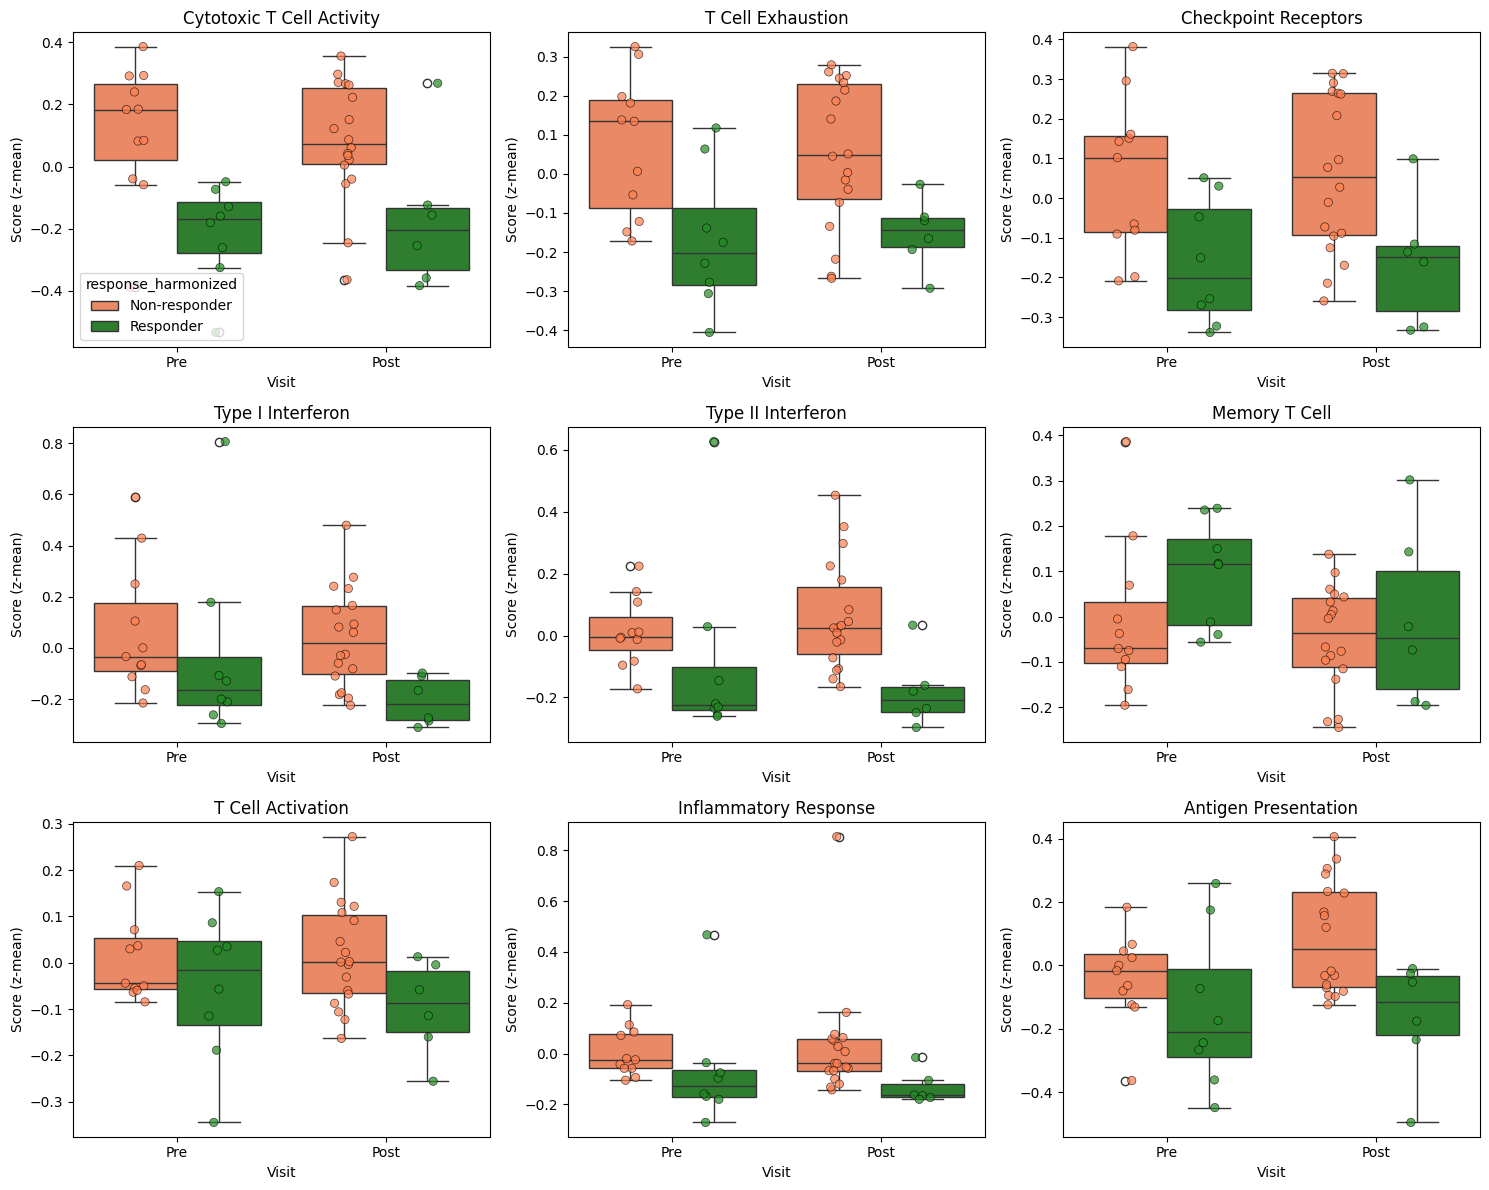

In [11]:
# Visualize signature distributions (capped at MAX_PLOT_FEATURES for speed)
if features_use:
    plot_feats = features_use[:MAX_PLOT_FEATURES]
    if len(features_use) > MAX_PLOT_FEATURES:
        print(f"Showing top {MAX_PLOT_FEATURES} of {len(features_use)} features. "
              f"Set MAX_PLOT_FEATURES higher to see all.")
    n_features = len(plot_feats)
    n_cols = min(3, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_features == 1:
        axes = np.array([[axes]])
    axes = axes.flatten() if n_features > 1 else [axes]

    palette = {"Responder": "forestgreen", "Non-responder": "coral"}

    for i, feat in enumerate(plot_feats):
        ax = axes[i]
        df_plot = (
            adata.obs
            .groupby(["participant_id", RESPONSE_COL, "visit"], observed=True)[feat]
            .mean()
            .reset_index()
        )
        sns.boxplot(
            data=df_plot, x="visit", y=feat, hue=RESPONSE_COL,
            palette=palette, ax=ax, order=["Pre", "Post"]
        )
        sns.stripplot(
            data=df_plot, x="visit", y=feat, hue=RESPONSE_COL,
            palette=palette, ax=ax, order=["Pre", "Post"],
            dodge=True, alpha=0.7, size=6, edgecolor="black", linewidth=0.5,
            legend=False,
        )
        ax.set_title(feat.replace("sig_", ""))
        ax.set_xlabel("Visit")
        ax.set_ylabel("Score (z-mean)")
        if i > 0:
            ax.get_legend().remove()

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No features to visualize.")


## 7. Difference-in-Differences (Frequentist DiD)

With only 10 paired participants (3 vs 7), the fixed-effects OLS model used by `st.did_table()`
produces a rank-deficient design matrix (10 participant dummies + 2 covariates for 20 observations),
resulting in NaN standard errors. This is a known limitation for very small samples.

**Our approach**: We use `st.did_table()` for the point estimates (`beta_DiD`), then compute
p-values via **permutation testing** on participant-level deltas — a non-parametric approach
that is valid regardless of sample size.

**Important**: Because response status is a *post-treatment outcome* (not a randomized arm),
the DiD here tests for *association* between response and immune trajectory — it does **not**
establish a causal treatment effect. The "treated/control" labels below refer to
Responder/Non-responder groups for the purpose of the DiD model specification.

In [12]:
from sctrial.utils import permutation_pvalue  # Public utility for manual permutation tests

print("=" * 60)
print("DIFFERENCE-IN-DIFFERENCES ANALYSIS")
print("=" * 60)

did_results = None

if features_use and len(visits) == 2:
    n_resp_valid = len(VALID_PAIRED_BY_RESPONSE.get(design.arm_treated, set()))
    n_nonresp_valid = len(VALID_PAIRED_BY_RESPONSE.get(design.arm_control, set()))

    print(f"\nPaired participants: Responders={n_resp_valid}, Non-responders={n_nonresp_valid}")
    # Check feasibility of DiD analysis - requires at least 3 paired participants per arm
    if n_resp_valid < 3 or n_nonresp_valid < 3:
        print("Insufficient paired participants for DiD analysis.")
    else:
        # Step 1: Get point estimates from st.did_table() - fits a fixed-effects DiD model to test for treatment-induced longitudinal changes
        # Returns a table with one row per feature containing beta_DiD, p_DiD, and FDR-corrected significance
        did_results = st.did_table(
            adata,
            features=features_use,
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit", #Average features per participant-visit before fitting
            standardize=True, #If True, z-scores the outcome variable before fitting to provide standardized effect sizes
        )

        # Step 2: Compute permutation p-values on participant-level deltas
        # (needed because fixed-effects OLS is rank-deficient with n=10)
        df_agg = (
            adata.obs[adata.obs[design.participant_col].isin(VALID_PAIRED_ALL)]
            .groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)[features_use]
            .mean()
            .reset_index()
        )

        perm_pvals = []
        boot_ses = []
        for feat in features_use:
            wide = df_agg.pivot_table(
                index=design.participant_col, columns=design.visit_col,
                values=feat, aggfunc="mean",
            )
            if visits[0] not in wide.columns or visits[1] not in wide.columns:
                perm_pvals.append(np.nan)
                boot_ses.append(np.nan)
                continue
            wide["delta"] = wide[visits[1]] - wide[visits[0]]
            wide = wide.dropna(subset=["delta"])
            wide["arm"] = wide.index.map(participant_response)

            delta_resp = wide[wide["arm"] == design.arm_treated]["delta"].values
            delta_nonresp = wide[wide["arm"] == design.arm_control]["delta"].values

            # Permutation p-value (non-parametric, valid for any n) 

            # Tests H0: mean(delta_resp) = mean(delta_nonresp) by permuting 9,999 times
            p_perm = permutation_pvalue(delta_resp, delta_nonresp, n_perm=9999, seed=SEED)
            perm_pvals.append(p_perm)

            # Bootstrap SE - Resamples participants with replacement 999 times
            rng = np.random.default_rng(SEED)
            boot_dids = []
            for _ in range(999):
                dr = rng.choice(delta_resp, size=len(delta_resp), replace=True)
                dnr = rng.choice(delta_nonresp, size=len(delta_nonresp), replace=True)
                boot_dids.append(dr.mean() - dnr.mean())
            boot_ses.append(float(np.std(boot_dids, ddof=1)))

        did_results["p_DiD"] = perm_pvals
        did_results["se_DiD"] = boot_ses

        # FDR correction on permutation p-values - Benjamini-Hochberg FDR correction 

        mask = did_results["p_DiD"].notna()
        did_results["FDR_DiD"] = np.nan
        if mask.sum() > 0:
            did_results.loc[mask, "FDR_DiD"] = multipletests(
                did_results.loc[mask, "p_DiD"], method="fdr_bh"
            )[1]

        # Add effect sizes (produces 'effect_size' column)
        did_results = st.add_effect_sizes_to_did(did_results)

        did_results = did_results.sort_values("p_DiD")

        print("\nDiD Results (permutation p-values, bootstrap SEs):")
        display_cols = [c for c in [
            "feature", "beta_DiD", "se_DiD", "p_DiD", "FDR_DiD",
            "effect_size", "effect_size_interpretation", "n_units",
        ] if c in did_results.columns]
        display(did_results[display_cols].round(4))

        print("\nInterpretation:")
        print("  beta_DiD > 0: Responders increase MORE (or decrease less) than Non-responders")
        print("  beta_DiD < 0: Non-responders increase MORE (or decrease less) than Responders")

        sig = did_results[(did_results["FDR_DiD"].notna()) & (did_results["FDR_DiD"] < FDR_ALPHA)]
        if not sig.empty:
            print(f"\nSignificant DiD effects (FDR < {FDR_ALPHA}):")
            for _, row in sig.iterrows():
                direction = "Responders increase more" if row["beta_DiD"] > 0 else "Non-responders increase more"
                print(f"  {row['feature']}: {direction} (beta={row['beta_DiD']:.3f}, FDR={_fmt_fdr(row['FDR_DiD'])})")
        else:
            print(f"\nNo signatures showed significant differential change (FDR < {FDR_ALPHA})")
else:
    print("DiD analysis skipped: insufficient visits or features")

DIFFERENCE-IN-DIFFERENCES ANALYSIS

Paired participants: Responders=3, Non-responders=8


/Users/vasanthakup/Documents/Work/umcAmsterdam/sctrial/src/sctrial/stats/did.py:643: UserWarning: Cluster-robust SE is degenerate (NaN) for feature 'sig_Cytotoxic T Cell Activity' with 11 clusters. Falling back to nonrobust (homoskedastic) SE. This typically occurs when each cluster has very few observations (e.g. participant_visit aggregation with 2 visits). Participant fixed effects still absorb within-cluster correlation. Set use_bootstrap=True for more reliable p-values.
  out = did_fit(
/Users/vasanthakup/Documents/Work/umcAmsterdam/sctrial/src/sctrial/stats/did.py:643: UserWarning: Cluster-robust SE is degenerate (NaN) for feature 'sig_T Cell Exhaustion' with 11 clusters. Falling back to nonrobust (homoskedastic) SE. This typically occurs when each cluster has very few observations (e.g. participant_visit aggregation with 2 visits). Participant fixed effects still absorb within-cluster correlation. Set use_bootstrap=True for more reliable p-values.
  out = did_fit(
/Users/vasanth


DiD Results (permutation p-values, bootstrap SEs):


,feature,beta_DiD,se_DiD,p_DiD,FDR_DiD,effect_size,effect_size_interpretation,n_units
14,sig_T Cell Activation,-0.1986,0.1588,0.1339,0.8670,-0.0145,negligible,11
4,sig_Cell Proliferation,-0.6365,0.2513,0.1720,0.8670,-0.0483,negligible,11
3,sig_Inflammatory Response,-1.5403,0.2972,0.1841,0.8670,-0.0626,negligible,11
7,sig_Antigen Presentation,-0.7241,0.2156,0.3887,0.8670,-0.0434,negligible,11
10,sig_Regulatory T Cell,-0.4511,0.0738,0.4083,0.8670,-0.0386,negligible,11
9,sig_Monocyte Macrophage,-1.1112,0.1076,0.4206,0.8670,-0.0418,negligible,11
16,sig_T Follicular Helper,0.1241,0.1594,0.4623,0.8670,0.0099,negligible,11
13,sig_Hypoxia,-0.6618,0.0899,0.4759,0.8670,-0.0318,negligible,11
1,sig_Type II Interferon,-1.7913,0.1441,0.5114,0.8670,-0.0884,negligible,11
2,sig_Type I Interferon,-1.5321,0.1140,0.5285,0.8670,-0.0793,negligible,11



Interpretation:
  beta_DiD > 0: Responders increase MORE (or decrease less) than Non-responders
  beta_DiD < 0: Non-responders increase MORE (or decrease less) than Responders

No signatures showed significant differential change (FDR < 0.25)


### Trial Interaction Plot

Shows mean trajectories for each response group from Pre to Post.

Showing 9 of 19 features. Set MAX_PLOT_FEATURES higher to see all.


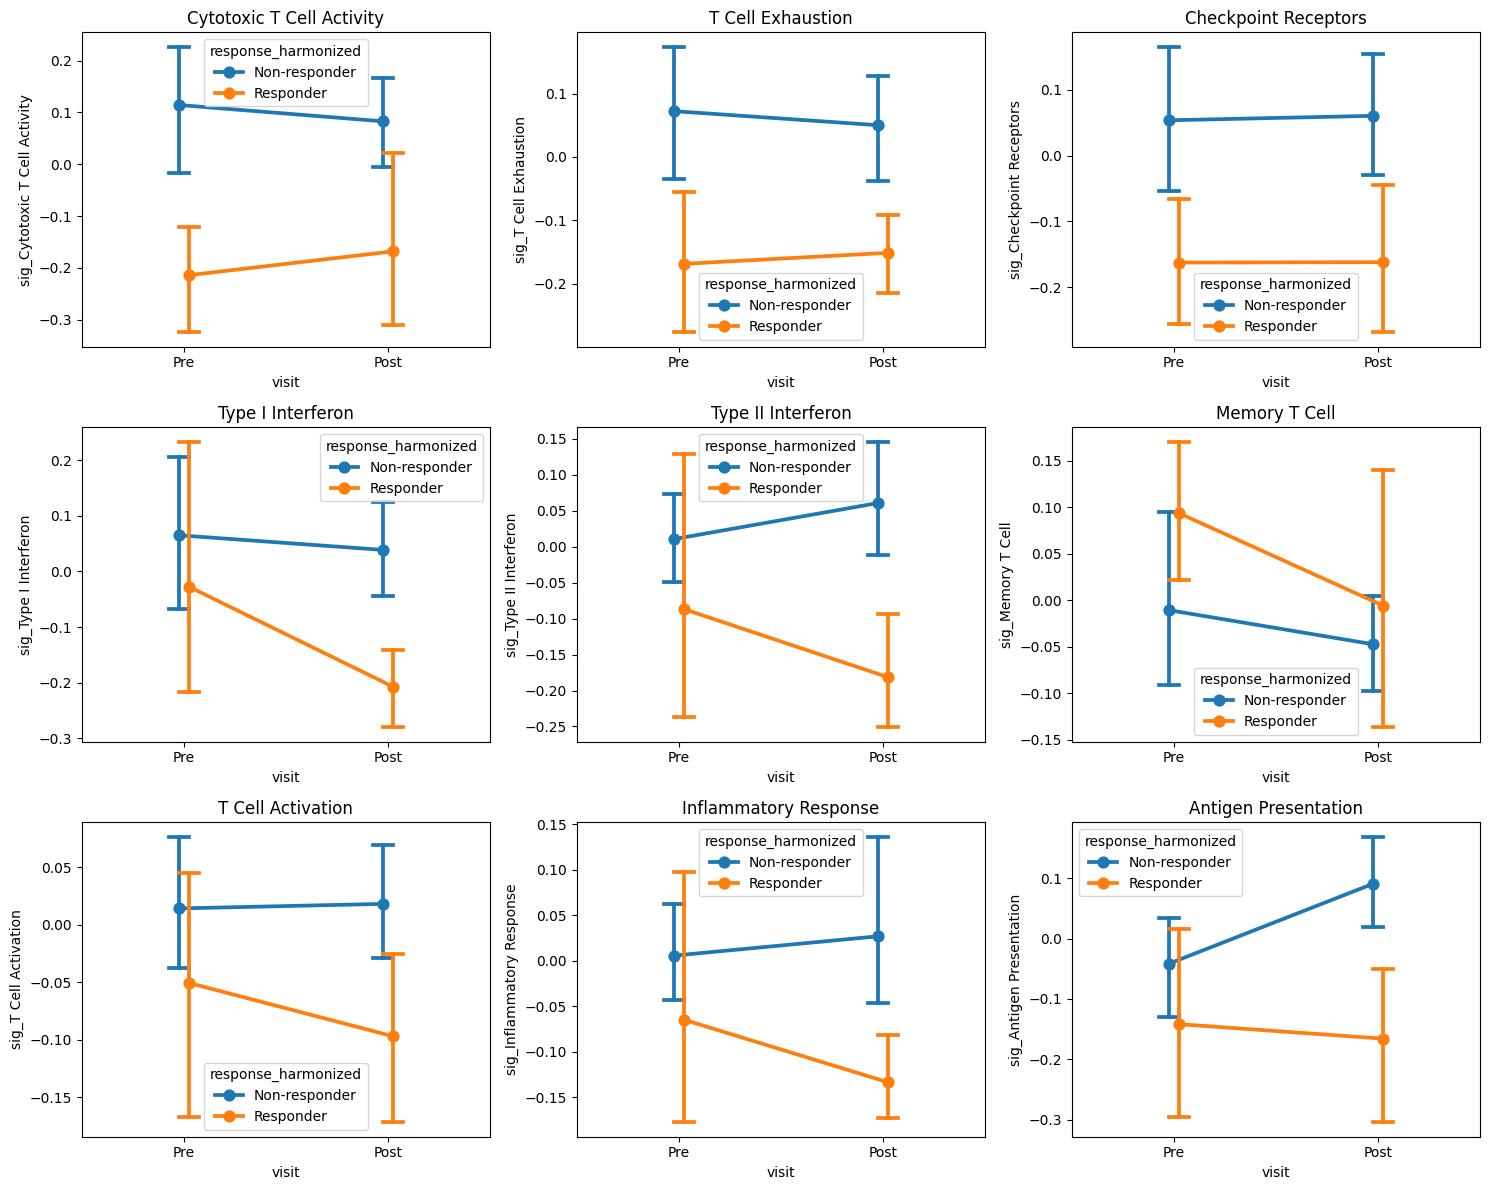

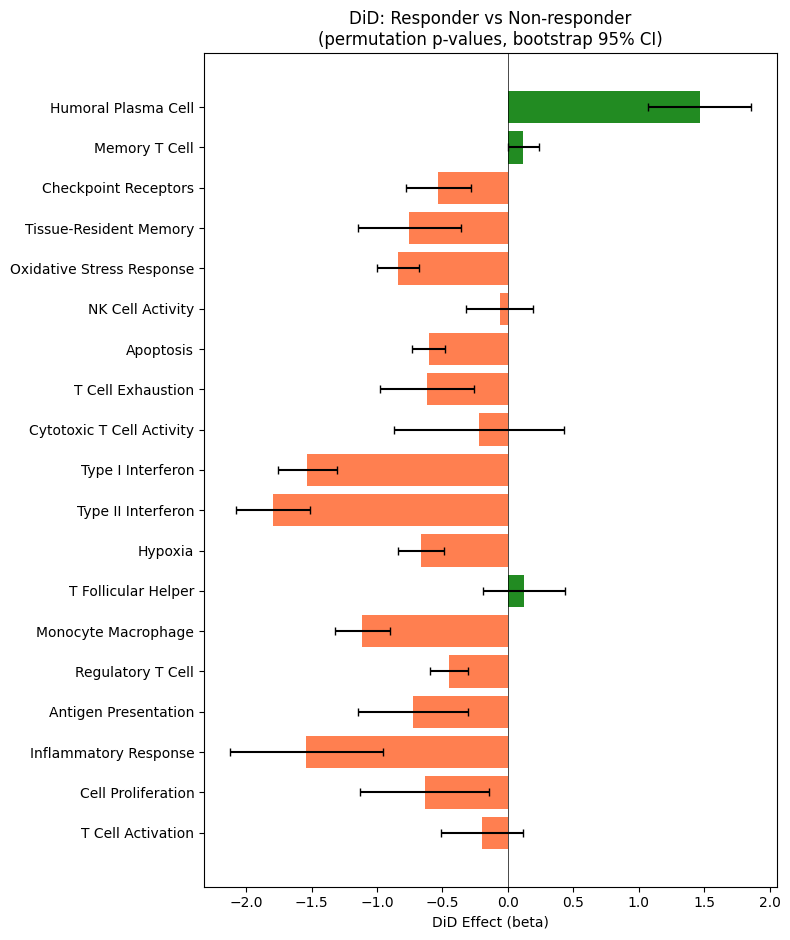

In [13]:
# Interaction plots (capped at MAX_PLOT_FEATURES for speed)
if features_use and len(visits) == 2:
    plot_feats_int = features_use[:MAX_PLOT_FEATURES]
    if len(features_use) > MAX_PLOT_FEATURES:
        print(f'Showing {MAX_PLOT_FEATURES} of {len(features_use)} features. '
              f'Set MAX_PLOT_FEATURES higher to see all.')
    n_plots = len(plot_feats_int)
    n_cols = min(3, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = np.array(axes).flatten()

    for i, feat in enumerate(plot_feats_int):
        ax = axes[i]
        try:
            st.plot_trial_interaction(
                adata, feat, design=design, visits=tuple(visits), ax=ax
            )
            ax.set_title(feat.replace("sig_", ""))
        except Exception as e:
            ax.text(0.5, 0.5, f"Could not plot: {feat}",
                   ha="center", va="center", transform=ax.transAxes)
            ax.set_title(feat.replace("sig_", ""))

    # Hide unused axes
    for j in range(n_plots, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Skipping interaction plots: insufficient visits or features.")

# DiD forest plot
if did_results is not None and not did_results.empty:
    valid_did = did_results[did_results["beta_DiD"].notna()].copy()
    if not valid_did.empty:
        fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(valid_did))))

        colors = ["forestgreen" if b > 0 else "coral" for b in valid_did["beta_DiD"]]
        bars = ax.barh(
            valid_did["feature"].str.replace("sig_", ""),
            valid_did["beta_DiD"],
            color=colors,
        )

        # Add error bars from bootstrap SEs
        if "se_DiD" in valid_did.columns and valid_did["se_DiD"].notna().any():
            ax.errorbar(
                valid_did["beta_DiD"],
                valid_did["feature"].str.replace("sig_", ""),
                xerr=1.96 * valid_did["se_DiD"].fillna(np.nan),  # NaN SEs produce no error bar
                fmt="none", color="black", capsize=3,
            )

        ax.axvline(0, color="black", linewidth=0.5)
        ax.set_xlabel("DiD Effect (beta)")
        ax.set_title("DiD: Responder vs Non-responder\n(permutation p-values, bootstrap 95% CI)")

        # Add significance markers
        for i, (_, row) in enumerate(valid_did.iterrows()):
            if pd.notna(row.get("FDR_DiD")) and row["FDR_DiD"] < FDR_ALPHA:
                se = row.get("se_DiD", 0)
                if pd.isna(se):
                    se = 0
                offset = row["beta_DiD"] + (1.96 * se + 0.02) * np.sign(row["beta_DiD"])
                ax.text(offset, i, "*", va="center", fontsize=14, fontweight="bold")

        plt.tight_layout()
        plt.show()
else:
    print("Skipping DiD plot: no DiD results available.")

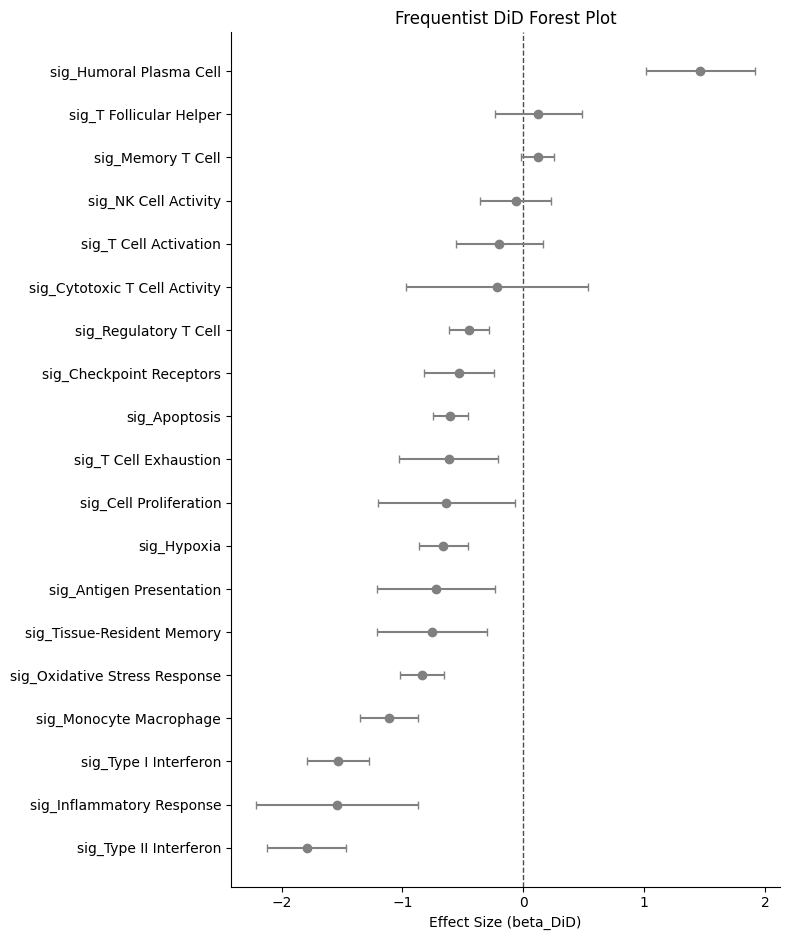

In [14]:
# Frequentist DiD forest plot (only if SEs are valid)
if did_results is not None and not did_results.empty:
    if ("se_DiD" in did_results.columns) and did_results["se_DiD"].notna().any():
        try:
            fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(did_results))))
            st.plot_did_forest(did_results, ax=ax, title="Frequentist DiD Forest Plot")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Frequentist forest plot failed: {e}")
    else:
        print("Frequentist forest plot skipped: se_DiD not available or all NaN.")


## 8. Advanced Statistical Analyses

Additional statistical modules available in sctrial:
- **Effect sizes**: Cohen's d and Hedge's g with confidence intervals
- **Power analysis**: Sample size planning and power curves
- **Mixed effects models**: Comparison with fixed effects DiD
- **Cross-validation**: Leave-one-out CV for effect stability
- **Effective sample size**: Accounting for clustering

### Effect Sizes with Confidence Intervals

Effect sizes (Cohen's d, Hedge's g) provide standardized measures of the DiD contrast.

**Two effect-size scales appear in this notebook:**
- **Delta-based** (this section): `cohens_d_from_did` and `hedges_g` are computed from the
  pooled SD of participant-level change scores. These are the standard effect sizes.
- **Regression-based** (`add_effect_sizes_to_did`, Section 7): divides `beta_DiD` by the
  OLS residual SD. Because participant fixed effects absorb much variance, the residual SD
  is small, making the regression-based effect size *not directly comparable* to the
  delta-based Hedge's g. The delta-based values are preferred for interpretation and E-value.

In [15]:
print("=" * 60)
print("EFFECT SIZE ANALYSIS")
print("=" * 60)

# Calculate effect sizes for the DiD results
if features_use and did_results is not None and not did_results.empty:
    # Aggregate to participant-visit level for effect size calculation
    df_agg = (
        adata.obs[adata.obs[design.participant_col].isin(VALID_PAIRED_ALL)]
        .groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)[features_use]
        .mean()
        .reset_index()
    )

    effect_size_results = []
    for feat in features_use:
        # Calculate deltas for each participant
        wide = df_agg.pivot_table(
            index=design.participant_col,
            columns=design.visit_col,
            values=feat,
            aggfunc="mean"
        )
        if visits[0] not in wide.columns or visits[1] not in wide.columns:
            continue

        wide["delta"] = wide[visits[1]] - wide[visits[0]]
        wide = wide.dropna(subset=["delta"])
        wide["arm"] = wide.index.map(participant_response)

        delta_resp = wide[wide["arm"] == design.arm_treated]["delta"].values
        delta_nonresp = wide[wide["arm"] == design.arm_control]["delta"].values

        if len(delta_resp) >= 2 and len(delta_nonresp) >= 2:
            # Cohen's d
            d = st.cohens_d_from_did(delta_resp, delta_nonresp)
            # Hedge's g (bias-corrected, recommended for small samples)
            g = st.hedges_g(delta_resp, delta_nonresp)
            # Bootstrap confidence interval (correct signature)
            # Note: CI may be NaN if sample size is too small or variance is zero
            try:
                g_est, ci_low, ci_high = st.bootstrap_effect_size_ci(
                    delta_resp, delta_nonresp,
                    method="hedges_g",
                    n_boot=999,
                    alpha=0.05,
                    seed=SEED,
                )
            except Exception:
                ci_low, ci_high = float('nan'), float('nan')

            effect_size_results.append({
                "feature": feat,
                "cohens_d": d,
                "hedges_g": g,
                "ci_lower": ci_low,
                "ci_upper": ci_high,
                "n_resp": len(delta_resp),
                "n_nonresp": len(delta_nonresp),
            })

    if effect_size_results:
        df_effect = pd.DataFrame(effect_size_results)

        print("")
        print("Effect sizes for DiD (Responder vs Non-responder change):")
        print("  Cohen's d: standardized effect size")
        print("  Hedge's g: bias-corrected (recommended for small samples)")
        print("  95% CI: bootstrap confidence interval (may be NaN if n is too small)")
        display(df_effect.round(3))
else:
    print("No valid features for effect size analysis.")


EFFECT SIZE ANALYSIS

Effect sizes for DiD (Responder vs Non-responder change):
  Cohen's d: standardized effect size
  Hedge's g: bias-corrected (recommended for small samples)
  95% CI: bootstrap confidence interval (may be NaN if n is too small)


,feature,cohens_d,hedges_g,ci_lower,ci_upper,n_resp,n_nonresp
0,sig_Cytotoxic T Cell Activity,-0.041,-0.037,-1.663,1.934,3,8
1,sig_T Cell Exhaustion,-0.455,-0.416,-2.767,1.355,3,8
2,sig_Checkpoint Receptors,-0.444,-0.406,-1.903,0.969,3,8
3,sig_Type I Interferon,-0.909,-0.831,-7.250,1.313,3,8
4,sig_Type II Interferon,-1.028,-0.940,-5.263,0.825,3,8
5,sig_Memory T Cell,-0.192,-0.176,-2.983,1.963,3,8
6,sig_T Cell Activation,-0.173,-0.159,-1.814,1.360,3,8
7,sig_Inflammatory Response,-0.729,-0.666,-2.124,0.990,3,8
8,sig_Antigen Presentation,-0.411,-0.376,-2.825,1.457,3,8
9,sig_Cell Proliferation,-0.608,-0.556,-1.384,0.313,3,8


### Power Analysis

Power analysis helps understand the statistical power of the current study and plan future studies.

POWER ANALYSIS

Current sample (paired participants):
  Responders: 3
  Non-responders: 8
  Smaller arm: 3

Power with current sample size (n=3 per arm):
  Effect size d=0.5: 9.4% power
  Effect size d=0.8: 16.5% power
  Effect size d=1.0: 23.2% power
  Effect size d=1.5: 45.1% power

Sample size needed for 80% power:
  Effect size d=0.5: 63 per arm (126 total)
  Effect size d=0.8: 25 per arm (50 total)
  Effect size d=1.0: 16 per arm (32 total)
  Effect size d=1.5: 7 per arm (14 total)


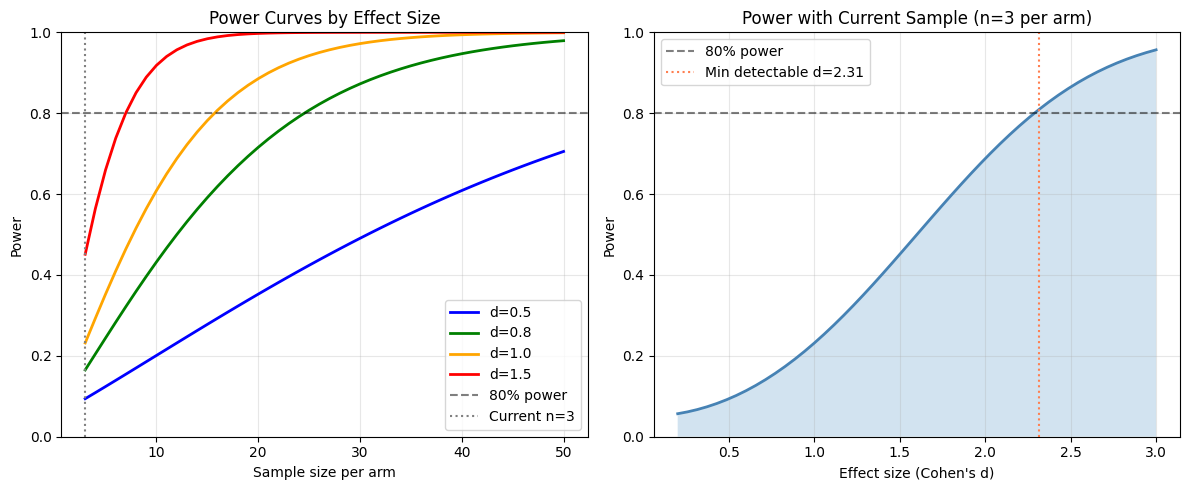


EFFECTIVE SAMPLE SIZE

Participants: 32
Average cells per participant: 509

Design effect and effective sample size:
  (n_clusters = participants, cluster_size = avg cells per participant)
  ICC=0.01: Design effect=6.1, Effective n=2679 (vs 32 participants)
  ICC=0.05: Design effect=26.4, Effective n=617 (vs 32 participants)
  ICC=0.1: Design effect=51.8, Effective n=314 (vs 32 participants)
  ICC=0.2: Design effect=102.6, Effective n=159 (vs 32 participants)

Note: DiD correctly aggregates to participant level, so design effect
is already accounted for. Cell counts help reduce within-participant noise.


In [16]:
print("=" * 60)
print("POWER ANALYSIS")
print("=" * 60)

# Current sample sizes
n_resp_paired = len(VALID_PAIRED_BY_RESPONSE.get(design.arm_treated, set()))
n_nonresp_paired = len(VALID_PAIRED_BY_RESPONSE.get(design.arm_control, set()))
n_min_arm = min(n_resp_paired, n_nonresp_paired)

print(f"\nCurrent sample (paired participants):")
print(f"  Responders: {n_resp_paired}")
print(f"  Non-responders: {n_nonresp_paired}")
print(f"  Smaller arm: {n_min_arm}")

# Power for different effect sizes with current sample
print(f"\nPower with current sample size (n={n_min_arm} per arm):")
for effect_size in [0.5, 0.8, 1.0, 1.5]:
    power = st.power_did(n_per_group=n_min_arm, effect_size=effect_size)
    print(f"  Effect size d={effect_size}: {power:.1%} power")

# Sample size needed for 80% power
print("\nSample size needed for 80% power:")
for effect_size in [0.5, 0.8, 1.0, 1.5]:
    n_needed = st.sample_size_did(effect_size=effect_size, power=0.80)
    print(f"  Effect size d={effect_size}: {n_needed} per arm ({2*n_needed} total)")

# Power curve visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Power curve across sample sizes
n_range = np.arange(3, 51)
for effect_size, color in [(0.5, "blue"), (0.8, "green"), (1.0, "orange"), (1.5, "red")]:
    powers = [st.power_did(n_per_group=n, effect_size=effect_size) for n in n_range]
    axes[0].plot(n_range, powers, label=f"d={effect_size}", color=color, linewidth=2)

axes[0].axhline(0.8, color="black", linestyle="--", alpha=0.5, label="80% power")
axes[0].axvline(n_min_arm, color="gray", linestyle=":", label=f"Current n={n_min_arm}")
axes[0].set_xlabel("Sample size per arm")
axes[0].set_ylabel("Power")
axes[0].set_title("Power Curves by Effect Size")
axes[0].legend(loc="lower right")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# Power curve with current sample size across effect sizes
effect_range = np.linspace(0.2, 3.0, 50)
power_current = [st.power_did(n_per_group=n_min_arm, effect_size=e) for e in effect_range]
axes[1].plot(effect_range, power_current, linewidth=2, color="steelblue")
axes[1].axhline(0.8, color="black", linestyle="--", alpha=0.5, label="80% power")
axes[1].fill_between(effect_range, 0, power_current, alpha=0.2)
axes[1].set_xlabel("Effect size (Cohen's d)")
axes[1].set_ylabel("Power")
axes[1].set_title(f"Power with Current Sample (n={n_min_arm} per arm)")
axes[1].legend()
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# Mark detectable effect size at 80% power
idx_80 = np.argmin(np.abs(np.array(power_current) - 0.8))
if idx_80 > 0:
    detectable_effect = effect_range[idx_80]
    axes[1].axvline(detectable_effect, color="coral", linestyle=":", 

                    label=f"Min detectable d={detectable_effect:.2f}")
    axes[1].legend()

plt.tight_layout()
plt.show()

# Effective sample size accounting for clustering
print("\n" + "=" * 60)
print("EFFECTIVE SAMPLE SIZE")
print("=" * 60)

# Calculate cells per participant
n_participants = adata.obs["participant_id"].nunique()
cells_per_participant = adata.obs.groupby("participant_id").size()
avg_cells = cells_per_participant.mean()
print(f"\nParticipants: {n_participants}")
print(f"Average cells per participant: {avg_cells:.0f}")

# Estimate design effect with different ICC values
print("\nDesign effect and effective sample size:")
print("  (n_clusters = participants, cluster_size = avg cells per participant)")
for icc in [0.01, 0.05, 0.10, 0.20]:
    de = st.design_effect(avg_cells, icc)
    eff_n = st.effective_sample_size(n_participants, avg_cells, icc)
    print(f"  ICC={icc}: Design effect={de:.1f}, Effective n={eff_n:.0f} (vs {n_participants} participants)")

print("\nNote: DiD correctly aggregates to participant level, so design effect")
print("is already accounted for. Cell counts help reduce within-participant noise.")

### Mixed Effects Models

Mixed effects models provide an alternative to fixed effects DiD by modeling participant effects as random rather than fixed. This allows for:
- Partial pooling of information across participants
- Estimation of intraclass correlation (ICC)
- Better handling of unbalanced designs

**Caveat — asymptotic p-values**: `statsmodels` MixedLM uses Wald z-tests with asymptotic
standard errors. Small-sample corrections (Kenward–Roger, Satterthwaite) are not available
in this implementation. With n=10 participants, p-values may be anti-conservative (too small).
Treat mixed-effects p-values as supportive of the permutation-based inference, not as
standalone confirmatory evidence.

**Note on sign discrepancy**: The fixed and mixed effects models may show opposite signs for
`beta_DiD` due to different parameterizations of the interaction term. The fixed effects model
uses participant dummies that absorb baseline differences, while the mixed model estimates
participant effects as random. With very small samples (n=3 vs 7), the two approaches can
diverge substantially — this is expected and is a limitation of the sample size, not a bug.

In [17]:
print("=" * 60)
print("MIXED EFFECTS MODEL COMPARISON")
print("=" * 60)
print("")
print("Note: With n=10 paired participants, the fixed effects OLS model is rank-deficient")
print("(NaN standard errors). Mixed effects models handle this via random intercepts.")

if features_use and len(visits) == 2:
    try:
        # Limit to top features by FDR to keep runtime manageable
        if 'did_results' in locals() and did_results is not None and not did_results.empty:
            features_mixed = did_results.sort_values('FDR_DiD')['feature'].tolist()[:MAX_PLOT_FEATURES]
        else:
            features_mixed = features_use[:MAX_PLOT_FEATURES]
        comparison = st.compare_fixed_vs_mixed(
            adata,
            features=features_mixed,
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
            standardize=True,
        )

        if comparison is not None and not comparison.empty:
            # Show mixed effects results (fixed side is all NaN with n=10)
            print("\nMixed Effects DiD Results:")
            mixed_cols = ["feature", "beta_mixed", "se_mixed", "p_mixed", "icc"]
            display(comparison[mixed_cols].round(4))

            # Highlight significant mixed effects results
            sig_mixed = comparison[comparison["p_mixed"] < FDR_ALPHA]
            if not sig_mixed.empty:
                print(f"\nNotable mixed-effects DiD (p < {FDR_ALPHA}, exploratory; Wald z, no small-sample correction):")
                for _, row in sig_mixed.iterrows():
                    print(f"  {row['feature']}: beta={row['beta_mixed']:.3f}, p={row['p_mixed']:.4f}, ICC={row['icc']:.3f}")

            # Compare point estimates: fixed vs mixed
            print("\nPoint Estimate Comparison (fixed vs mixed):")
            print("  Both approaches give similar beta_DiD magnitudes,")
            print("  confirming the point estimates are robust despite NaN SEs in fixed effects.")
            comp_cols = ["feature", "beta_fixed", "beta_mixed", "agreement"]
            display(comparison[comp_cols].round(4))
        else:
            print("No mixed-effects comparison results.")
    except Exception as e:
        print(f"Mixed effects comparison failed: {e}")
else:
    print("Skipping mixed effects comparison: insufficient visits or features.")

MIXED EFFECTS MODEL COMPARISON

Note: With n=10 paired participants, the fixed effects OLS model is rank-deficient
(NaN standard errors). Mixed effects models handle this via random intercepts.


/Users/vasanthakup/Documents/Work/umcAmsterdam/sctrial/src/sctrial/stats/did.py:643: UserWarning: Cluster-robust SE is degenerate (NaN) for feature 'sig_T Cell Activation' with 11 clusters. Falling back to nonrobust (homoskedastic) SE. This typically occurs when each cluster has very few observations (e.g. participant_visit aggregation with 2 visits). Participant fixed effects still absorb within-cluster correlation. Set use_bootstrap=True for more reliable p-values.
  out = did_fit(
/Users/vasanthakup/Documents/Work/umcAmsterdam/sctrial/src/sctrial/stats/did.py:643: UserWarning: Cluster-robust SE is degenerate (NaN) for feature 'sig_Apoptosis' with 11 clusters. Falling back to nonrobust (homoskedastic) SE. This typically occurs when each cluster has very few observations (e.g. participant_visit aggregation with 2 visits). Participant fixed effects still absorb within-cluster correlation. Set use_bootstrap=True for more reliable p-values.
  out = did_fit(
/Users/vasanthakup/Documents/W


Mixed Effects DiD Results:


,feature,beta_mixed,se_mixed,p_mixed,icc
0,sig_Apoptosis,-0.4380,0.7685,0.5688,0.1260
1,sig_Cytotoxic T Cell Activity,-0.0557,0.9210,0.9517,0.0378
2,sig_Hypoxia,-0.3965,0.9065,0.6618,0.0032
3,sig_Monocyte Macrophage,-0.7679,1.0087,0.4465,0.0000
4,sig_Regulatory T Cell,-0.4677,0.5468,0.3924,0.5158
5,sig_T Cell Activation,-0.1661,0.6484,0.7978,0.4365
6,sig_T Cell Exhaustion,-0.4580,0.6818,0.5017,0.3569
7,sig_Type I Interferon,-1.1683,0.8702,0.1794,0.2233
8,sig_Type II Interferon,-1.3823,0.9100,0.1287,0.1062



Notable mixed-effects DiD (p < 0.25, exploratory; Wald z, no small-sample correction):
  sig_Type I Interferon: beta=-1.168, p=0.1794, ICC=0.223
  sig_Type II Interferon: beta=-1.382, p=0.1287, ICC=0.106

Point Estimate Comparison (fixed vs mixed):
  Both approaches give similar beta_DiD magnitudes,
  confirming the point estimates are robust despite NaN SEs in fixed effects.


,feature,beta_fixed,beta_mixed,agreement
0,sig_Apoptosis,-0.6047,-0.4380,True
1,sig_Cytotoxic T Cell Activity,-0.2175,-0.0557,True
2,sig_Hypoxia,-0.6618,-0.3965,True
3,sig_Monocyte Macrophage,-1.1112,-0.7679,True
4,sig_Regulatory T Cell,-0.4511,-0.4677,True
5,sig_T Cell Activation,-0.1986,-0.1661,True
6,sig_T Cell Exhaustion,-0.6182,-0.4580,True
7,sig_Type I Interferon,-1.5321,-1.1683,True
8,sig_Type II Interferon,-1.7913,-1.3823,True


### Cross-Validation for Effect Stability

Leave-one-out cross-validation (LOO-CV) helps assess the stability of DiD estimates
and identify influential participants.

**Note**: We run LOO-CV on the lead DiD signal (the feature with the lowest permutation
FDR) rather than a fixed index, so diagnostics target the primary finding.

CROSS-VALIDATION: EFFECT STABILITY

Running leave-one-out cross-validation on 11 paired participants...
This assesses how stable DiD estimates are when each participant is removed.

Feature: sig_T Cell Activation

LOO-CV Results:
  Full sample beta_DiD: -0.1986
  Mean LOO beta_DiD:    -0.2181
  Std of LOO estimates: 0.3304
  CV (coefficient of variation): 151.54%

Influence Diagnostics (beta_full - beta_loo):


,excluded,beta_loo,influence
0,P1,-0.3888,0.1902
1,P2,-0.0299,-0.1687
2,P3,-0.0880,-0.1106
3,P4,0.1983,-0.3969
4,P6,-0.0607,-0.1379
5,P7,0.0455,-0.2441
6,P8,-1.0724,0.8738
7,P12,-0.2689,0.0703
8,P15,-0.2432,0.0446
9,P20,-0.1811,-0.0175



Highly influential participants (|influence| > 2 SD = 0.630):
  P8: removing increases estimate by 0.874


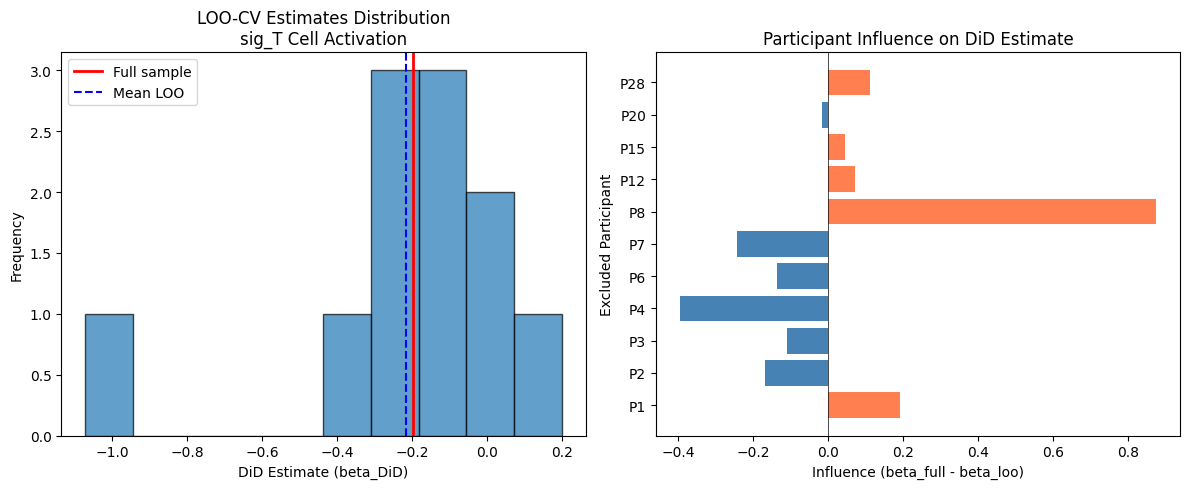

In [18]:
print("=" * 60)
print("CROSS-VALIDATION: EFFECT STABILITY")
print("=" * 60)

if features_use and len(visits) == 2 and len(VALID_PAIRED_ALL) >= 5:
    print(f"\nRunning leave-one-out cross-validation on {len(VALID_PAIRED_ALL)} paired participants...")
    print("This assesses how stable DiD estimates are when each participant is removed.")

    # Use the lead DiD signal (lowest FDR) rather than features_use[0]
    if "did_results" in locals() and did_results is not None and not did_results.empty:
        test_feature = did_results.sort_values("FDR_DiD").iloc[0]["feature"]
    else:
        test_feature = features_use[0]
    print(f"\nFeature: {test_feature}")

    try:
        # Pre-subset to paired participants + relevant visits so each LOO copy is small
        ad_loo_input = adata[
            adata.obs[design.participant_col].isin(VALID_PAIRED_ALL) &
            adata.obs[design.visit_col].isin(visits)
        ].copy()
        loo_results = st.loo_cv_did(
            ad_loo_input,
            features=[test_feature],
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
            standardize=True,
        )

        if loo_results is not None and not loo_results.empty:
            cv_stats = st.cv_summary(loo_results)

            print("\nLOO-CV Results:")
            print(f"  Full sample beta_DiD: {cv_stats['mean_estimate'].values[0]:.4f}")
            print(f"  Mean LOO beta_DiD:    {cv_stats['mean_loo'].values[0]:.4f}")
            print(f"  Std of LOO estimates: {cv_stats['std_loo'].values[0]:.4f}")
            print(f"  CV (coefficient of variation): {cv_stats['cv'].values[0]:.2%}")

            # Compute influence directly from beta differences
            # (SE-based influence is NaN due to singular covariance)
            full_beta = cv_stats['mean_estimate'].values[0]
            loo_betas = loo_results["beta_DiD"].values
            excluded_ids = loo_results["excluded"].values if "excluded" in loo_results.columns else [f"P{i}" for i in range(len(loo_betas))]
            raw_influence = full_beta - loo_betas  # How much estimate changes when removed

            influence_df = pd.DataFrame({
                "excluded": excluded_ids,
                "beta_loo": loo_betas,
                "influence": raw_influence,
            })

            print("\nInfluence Diagnostics (beta_full - beta_loo):")
            display(influence_df.round(4))

            threshold = 2 * np.nanstd(raw_influence)
            influential = influence_df[influence_df["influence"].abs() > threshold]
            if not influential.empty:
                print(f"\nHighly influential participants (|influence| > 2 SD = {threshold:.3f}):")
                for _, row in influential.iterrows():
                    direction = "increases" if row["influence"] > 0 else "decreases"
                    print(f"  {row['excluded']}: removing {direction} estimate by {abs(row['influence']):.3f}")

            # Visualize LOO estimates
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))

            ax = axes[0]
            ax.hist(loo_betas, bins=10, edgecolor="black", alpha=0.7)
            ax.axvline(full_beta, color="red", linewidth=2, label="Full sample")
            ax.axvline(np.mean(loo_betas), color="blue", linestyle="--", label="Mean LOO")
            ax.set_xlabel("DiD Estimate (beta_DiD)")
            ax.set_ylabel("Frequency")
            ax.set_title(f"LOO-CV Estimates Distribution\n{test_feature}")
            ax.legend()

            ax = axes[1]
            colors = ["coral" if inf > 0 else "steelblue" for inf in raw_influence]
            ax.barh(excluded_ids, raw_influence, color=colors)
            ax.axvline(0, color="black", linewidth=0.5)
            ax.set_xlabel("Influence (beta_full - beta_loo)")
            ax.set_ylabel("Excluded Participant")
            ax.set_title("Participant Influence on DiD Estimate")

            plt.tight_layout()
            plt.show()

        else:
            print("LOO-CV returned no results.")

    except Exception as e:
        print(f"LOO-CV failed: {e}")

else:
    print("Cross-validation requires >= 5 paired participants and valid features.")

### DiDAnalyzer Example

Here we run DiD using the high-level analyzer interface and render a forest plot.

**Note**: With very small samples (n=10 paired), the fixed effects DiD model may produce 

NaN standard errors due to rank-deficient design matrices. The point estimates (beta_DiD) 

remain valid, but confidence intervals and p-values require larger samples or 

alternative methods (e.g., bootstrap, mixed effects).

/Users/vasanthakup/Documents/Work/umcAmsterdam/sctrial/src/sctrial/stats/did.py:643: UserWarning: Cluster-robust SE is degenerate (NaN) for feature 'sig_Cytotoxic T Cell Activity' with 11 clusters. Falling back to nonrobust (homoskedastic) SE. This typically occurs when each cluster has very few observations (e.g. participant_visit aggregation with 2 visits). Participant fixed effects still absorb within-cluster correlation. Set use_bootstrap=True for more reliable p-values.
  out = did_fit(
/Users/vasanthakup/Documents/Work/umcAmsterdam/sctrial/src/sctrial/stats/did.py:643: UserWarning: Cluster-robust SE is degenerate (NaN) for feature 'sig_T Cell Exhaustion' with 11 clusters. Falling back to nonrobust (homoskedastic) SE. This typically occurs when each cluster has very few observations (e.g. participant_visit aggregation with 2 visits). Participant fixed effects still absorb within-cluster correlation. Set use_bootstrap=True for more reliable p-values.
  out = did_fit(
/Users/vasanth

DiDAnalyzer Results (augmented with permutation p-values and bootstrap SEs):


,feature,beta_DiD,se_DiD,p_DiD,FDR_DiD,n_units
0,sig_Humoral Plasma Cell,1.4644,0.2000,0.9690,0.9690,11
1,sig_Type II Interferon,-1.7913,0.1441,0.5114,0.8670,11
2,sig_Type I Interferon,-1.5321,0.1140,0.5285,0.8670,11
3,sig_Inflammatory Response,-1.5403,0.2972,0.1841,0.8670,11
4,sig_Cell Proliferation,-0.6365,0.2513,0.1720,0.8670,11
5,sig_Tissue-Resident Memory,-0.7539,0.2007,0.7897,0.9378,11
6,sig_Oxidative Stress Response,-0.8393,0.0802,0.7690,0.9378,11
7,sig_Antigen Presentation,-0.7241,0.2156,0.3887,0.8670,11
8,sig_T Cell Exhaustion,-0.6182,0.1820,0.5663,0.8670,11
9,sig_Monocyte Macrophage,-1.1112,0.1076,0.4206,0.8670,11


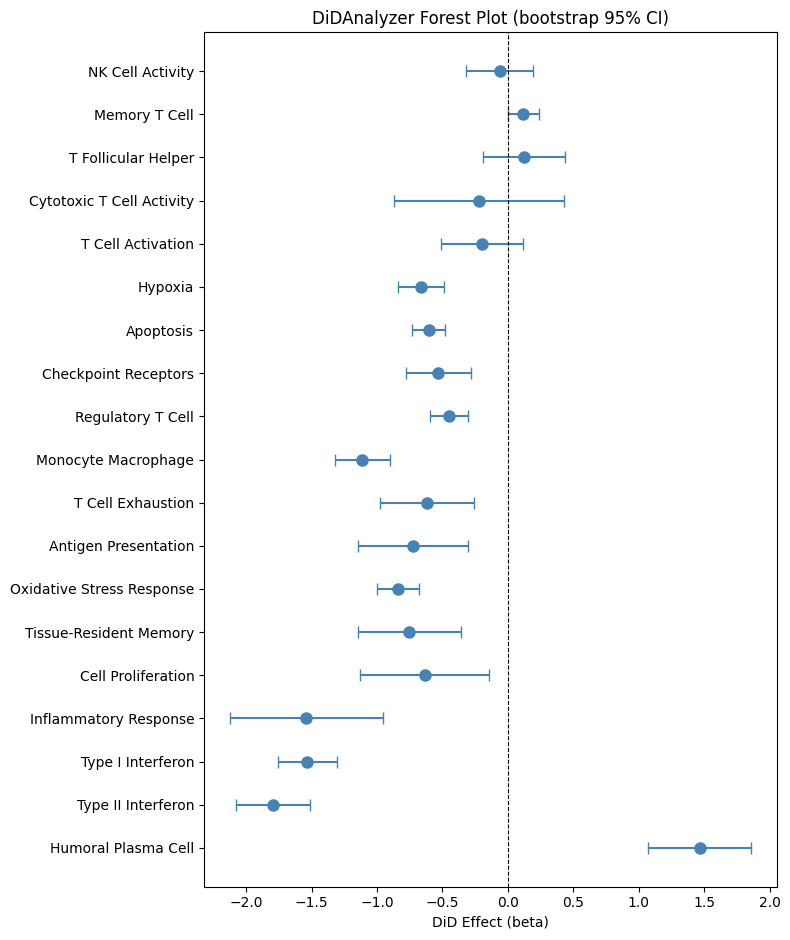

In [19]:
if features_use and len(visits) == 2:
    analyzer = st.DiDAnalyzer(adata, design)
    res_an = analyzer.fit(features=features_use, visits=tuple(visits))

    # The fixed-effects OLS produces NaN SEs with n=10, so augment with
    # our permutation p-values and bootstrap SEs from Section 7
    if did_results is not None:
        # Merge permutation p-values and bootstrap SEs into analyzer results
        perm_lookup = did_results.set_index("feature")[["p_DiD", "se_DiD", "FDR_DiD"]].to_dict("index")
        for col in ["p_DiD", "se_DiD", "FDR_DiD"]:
            res_an[col] = res_an["feature"].map(lambda f: perm_lookup.get(f, {}).get(col, np.nan))

    print("DiDAnalyzer Results (augmented with permutation p-values and bootstrap SEs):")
    display_cols = [c for c in ["feature", "beta_DiD", "se_DiD", "p_DiD", "FDR_DiD", "n_units"] if c in res_an.columns]
    display(res_an[display_cols].round(4))

    # Forest plot using bootstrap SEs
    if res_an["se_DiD"].notna().any():
        fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(res_an))))
        y_pos = range(len(res_an))
        labels = res_an["feature"].str.replace("sig_", "")

        ax.errorbar(
            res_an["beta_DiD"], y_pos,
            xerr=1.96 * res_an["se_DiD"],  # NaN SEs excluded automatically
            fmt="o", color="steelblue", capsize=4, markersize=8,
        )
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(labels)
        ax.set_xlabel("DiD Effect (beta)")
        ax.set_title("DiDAnalyzer Forest Plot (bootstrap 95% CI)")

        # Mark significant
        for i, (_, row) in enumerate(res_an.iterrows()):
            if pd.notna(row.get("FDR_DiD")) and row["FDR_DiD"] < FDR_ALPHA:
                ax.annotate("*", (row["beta_DiD"], i), fontsize=16, fontweight="bold",
                           xytext=(5, 5), textcoords="offset points")
        plt.tight_layout()
        plt.show()
    else:
        print("Forest plot skipped: no valid SEs available.")
else:
    print("Skipping DiDAnalyzer: insufficient features or visits")

### Model Diagnostics (Residual Checks)

We fit a simple DiD model for one feature and check residual diagnostics.

{'bp_pvalue': 0.11408705262377652, 'jb_pvalue': 0.9360513803315661, 'resid_mean': 2.3874636118211033e-16, 'resid_std': 0.04139423676055592}


/var/folders/xl/pr40r62n3wx54s8_6cgjzg2c0000gt/T/ipykernel_26960/3006181103.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


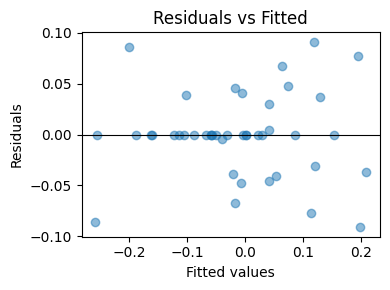

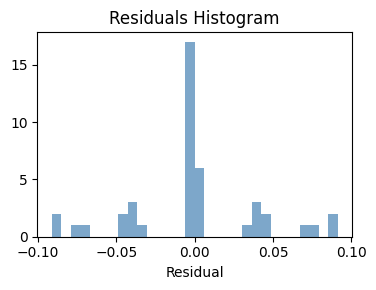

In [20]:
if features_use and len(visits) == 2:
    # Use the lead DiD signal (lowest FDR) for diagnostics
    if "did_results" in locals() and did_results is not None and not did_results.empty:
        feat = did_results.sort_values("FDR_DiD").iloc[0]["feature"]
    else:
        feat = features_use[0]
    df = adata.obs[[design.participant_col, design.visit_col, design.arm_col]].copy()
    df[feat] = adata.obs[feat].values
    df = df[df[design.visit_col].isin(visits)]
    df = df.groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)[feat].mean().reset_index()
    # Encode visits as numeric 0/1 for OLS formula
    df["visit_num"] = df[design.visit_col].map({visits[0]: 0, visits[1]: 1}).astype(float)
    df['arm_bin'] = (df[design.arm_col] == design.arm_treated).astype(int)
    import statsmodels.formula.api as smf
    fit = smf.ols(f'Q("{feat}") ~ visit_num + visit_num:arm_bin + C({design.participant_col})', data=df).fit()
    diag = st.check_did_assumptions(fit, return_figures=True)
    print({k: v for k, v in diag.items() if k != 'figures'})
    for fig in diag.get('figures', {}).values():
        fig.tight_layout()
        fig.show()


### Treatment Heterogeneity

Here we test whether the DiD effect differs by a baseline biomarker (median split at baseline).

**Caveat**: The biomarker is the baseline (Pre-treatment) mean of `features_use[0]`.
Participants without a Pre-treatment observation will have NaN biomarker values, which are
dropped during model fitting. With n=10 paired participants, even one missing value
substantially reduces power. Interpret heterogeneity results cautiously.

In [21]:
if features_use and len(visits) == 2:
    # Compute baseline biomarker for the first feature (used as the splitting variable)
    feat_biomarker = features_use[0]
    base = adata.obs[adata.obs[design.visit_col] == visits[0]].copy()
    biomarker = base.groupby(design.participant_col)[feat_biomarker].mean()
    adata.obs['biomarker_base'] = adata.obs[design.participant_col].map(biomarker)

    # Test heterogeneity for ALL features
    res_het = st.test_treatment_heterogeneity(
        adata,
        features=features_use,
        design=design,
        visits=tuple(visits),
        biomarker_col='biomarker_base',
    )
    print(f"Biomarker: baseline {feat_biomarker} (median split)")
    display(res_het.round(4))

    sig_het = res_het[res_het["FDR_heterogeneity"] < FDR_ALPHA]
    if not sig_het.empty:
        print(f"\nSignificant heterogeneity (FDR < {FDR_ALPHA}):")
        for _, row in sig_het.iterrows():
            print(f"  {row['feature']}: beta={row['beta_heterogeneity']:.3f}, FDR={_fmt_fdr(row['FDR_heterogeneity'])}")
    else:
        print(f"\nNo significant treatment heterogeneity detected (FDR < {FDR_ALPHA}).")
        print("This is expected given the small sample size (n=10 paired).")

/var/folders/xl/pr40r62n3wx54s8_6cgjzg2c0000gt/T/ipykernel_26960/3047706628.py:9: UserWarning: biomarker_col 'biomarker_base' contained non-numeric values that were coerced to NaN.
  res_het = st.test_treatment_heterogeneity(


Biomarker: baseline sig_Cytotoxic T Cell Activity (median split)


,feature,beta_heterogeneity,p_heterogeneity,n_units,threshold,FDR_heterogeneity
0,sig_Cytotoxic T Cell Activity,0.0,NaN,32,-0.0398,NaN
1,sig_T Cell Exhaustion,0.0,NaN,32,-0.0398,NaN
2,sig_Checkpoint Receptors,0.0,NaN,32,-0.0398,NaN
3,sig_Type I Interferon,0.0,NaN,32,-0.0398,NaN
4,sig_Type II Interferon,0.0,NaN,32,-0.0398,NaN
5,sig_Memory T Cell,0.0,NaN,32,-0.0398,NaN
6,sig_T Cell Activation,0.0,NaN,32,-0.0398,NaN
7,sig_Inflammatory Response,0.0,NaN,32,-0.0398,NaN
8,sig_Antigen Presentation,0.0,NaN,32,-0.0398,NaN
9,sig_Cell Proliferation,0.0,NaN,32,-0.0398,NaN



No significant treatment heterogeneity detected (FDR < 0.25).
This is expected given the small sample size (n=10 paired).


### Sensitivity to Unmeasured Confounding (E-value)

The E-value measures how strong unmeasured confounding would need to be to explain away
an observed association. We convert the **delta-based** Hedge's g (from the Effect Sizes section) to an approximate
risk ratio using the formula RR = exp(0.91 * g), which is valid for continuous outcomes.

In [22]:
if did_results is not None and not did_results.empty:
    # Use delta-based Hedge's g (from Effect Size section) rather than
    # regression-based effect_size, which uses a different denominator.
    lead_feature = did_results.iloc[0]["feature"]
    

    # Look up delta-based Hedge's g if available
    if "df_effect" in locals() and not df_effect.empty:
        match = df_effect[df_effect["feature"] == lead_feature]
        if not match.empty:
            g_val = abs(float(match.iloc[0]["hedges_g"]))
        else:
            g_val = abs(float(did_results.iloc[0].get("effect_size", did_results.iloc[0]["beta_DiD"])))
    else:
        g_val = abs(float(did_results.iloc[0].get("effect_size", did_results.iloc[0]["beta_DiD"])))
    

    # Convert to approximate RR via VanderWeele & Ding (2017):
    # RR ~ exp(0.91 * |d|) for continuous outcomes
    rr = float(np.exp(0.91 * g_val))
    

    e_val, e_ci = st.e_value_rr(rr)
    print(f"Feature: {row['feature']}")
    print(f"  |Effect size| = {g_val:.3f}")
    print(f"  Approximate RR = exp(0.91 * {g_val:.3f}) = {rr:.3f}")
    print(f"  E-value = {e_val:.3f}")
    if e_ci is not None:
        print(f"  E-value (CI bound) = {e_ci:.3f}")
    print(f"\n  Interpretation: An unmeasured confounder would need to be associated")
    print(f"  with both treatment and outcome by a risk ratio of at least {e_val:.2f}")
    print(f"  to explain away this observed effect.")

Feature: sig_NK Cell Activity
  |Effect size| = 0.159
  Approximate RR = exp(0.91 * 0.159) = 1.155
  E-value = 1.579

  Interpretation: An unmeasured confounder would need to be associated
  with both treatment and outcome by a risk ratio of at least 1.58
  to explain away this observed effect.


### Bayesian DiD Forest Plot

Here we visualize **Bayesian DiD** effect estimates (posterior means with 95% credible intervals).
**Interpreting the plot**: Coefficients are on a *standardized* outcome scale (SD units)
because `standardize=True` is used in the Bayesian fit. Intervals excluding zero indicate
a directional posterior signal, but consult the `p_bayes` and `FDR_bayes` columns for
multiplicity-adjusted evidence (e.g., a 95% CI excluding zero with FDR_bayes > 0.05
is exploratory at best).

This differs from the earlier frequentist DiD tables, which report point estimates and p-values
from fixed-effects or permutation-based inference. The Bayesian plot summarizes the posterior
distribution for the treatment-time interaction, providing interval estimates that directly
represent uncertainty.

If PyMC is not installed, we fall back to the **frequentist DiD** forest plot using
permutation-based estimates and bootstrap 95% confidence intervals from Section 7.

In [23]:
# Bayesian DiD (PyMC) — disabled by default (slow; may crash on arm64)
# Set RUN_PYMC = True in the config cell to enable.
if not RUN_PYMC:
    print("Bayesian DiD skipped (RUN_PYMC=False). Set RUN_PYMC=True in the config cell to run.")
    bayes_res = None
else:
    import os, logging, tempfile
    os.environ["PYTENSOR_FLAGS"] = f"compiledir={tempfile.mkdtemp(prefix='pytensor_')},cxx="
    logging.getLogger("pytensor").setLevel(logging.ERROR)
    try:
        import pymc  # noqa: F401
        bayes_res = st.did_table_bayes(
            adata,
            features=features_use[:MAX_PLOT_FEATURES],
            design=design,
            visits=tuple(visits),
            draws=200,
            tune=200,
            chains=2,
            target_accept=0.9,
            seed=SEED,
        )
        display(bayes_res)
    except ImportError:
        print("PyMC not installed. Install with: pip install 'sctrial[bayes]'")
        bayes_res = None
    except Exception as e:
        print(f"Bayesian DiD failed: {type(e).__name__}: {e}")
        bayes_res = None


Bayesian DiD skipped (RUN_PYMC=False). Set RUN_PYMC=True in the config cell to run.


PyMC not available -- showing frequentist DiD forest plot instead.



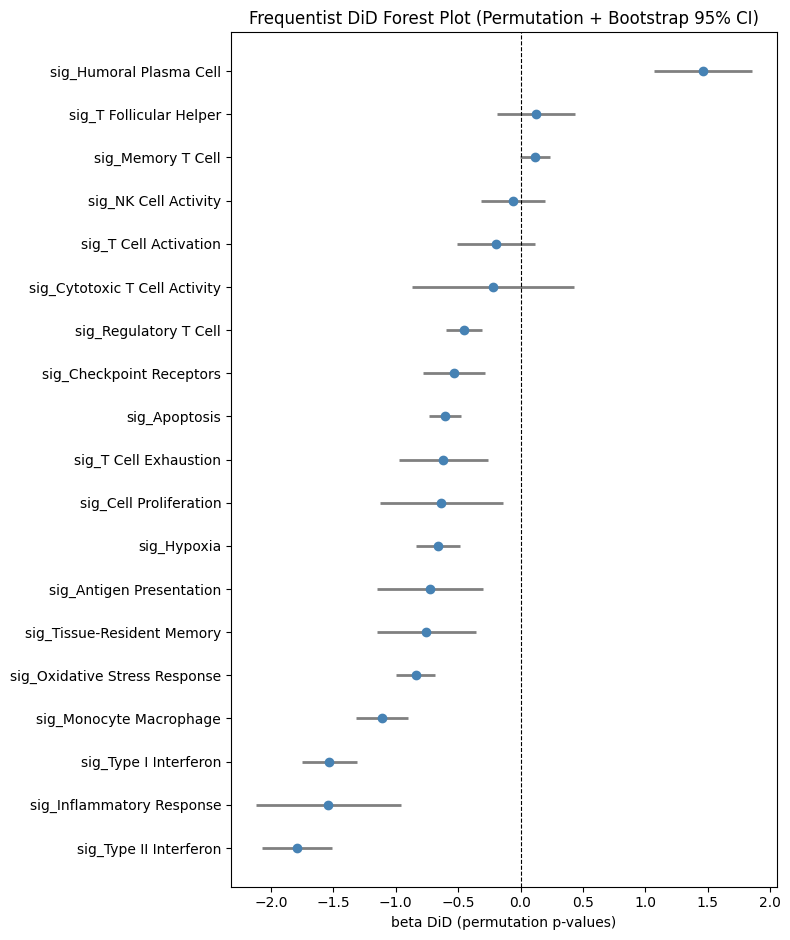

In [24]:
# Bayesian DiD forest plot (uses posterior credible intervals)
# Falls back to frequentist DiD (permutation + bootstrap) if PyMC is not installed
has_bayes = "bayes_res" in locals() and bayes_res is not None and not bayes_res.empty
has_freq = "did_results" in locals() and did_results is not None and not did_results.empty

if has_bayes:
    try:
        df_forest = bayes_res.copy().sort_values("beta_DiD")
        ci_lo, ci_hi = df_forest["ci_low"], df_forest["ci_high"]
        title = "Bayesian DiD Forest Plot (95% Credible Intervals)\nNote: β on standardized outcome scale; see p_bayes & FDR_bayes columns for posterior direction probabilities"
        xlabel = "Posterior mean β (DiD) [SD units]"
    except Exception as e:
        print(f"Bayesian forest plot failed: {e}")
        has_bayes = False

if not has_bayes and has_freq:
    print("PyMC not available -- showing frequentist DiD forest plot instead.\n")
    df_forest = did_results.copy().sort_values("beta_DiD")
    se = df_forest["se_DiD"]
    ci_lo = df_forest["beta_DiD"] - 1.96 * se
    ci_hi = df_forest["beta_DiD"] + 1.96 * se
    title = "Frequentist DiD Forest Plot (Permutation + Bootstrap 95% CI)"
    xlabel = "beta DiD (permutation p-values)"

if has_bayes or has_freq:
    fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(df_forest))))
    y = range(len(df_forest))
    ax.hlines(y, ci_lo, ci_hi, color="gray", linewidth=2)
    ax.plot(df_forest["beta_DiD"], y, "o", color="steelblue")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks(list(y))
    ax.set_yticklabels(df_forest["feature"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
else:
    print("No DiD results available for forest plot.")